# **IMPORTS**

In [1]:
# Standard Libraries
import ast
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import itertools

# Scikit-Learn: Preprocessing & Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

# Scikit-Learn: Model Selection & Validation
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, cross_val_predict

# Scikit-Learn: Models
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Scikit-Learn: Metrics
from sklearn.metrics import (mean_squared_error, r2_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report, accuracy_score)

# Google Colab specific
from google.colab import drive

In [2]:
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Datasets-DS_project/Smartphone_Specifications_Dataset.csv')

Mounted at /content/drive


# **CLEANING**

In [3]:
#----------------------------------------------------------------------------------------------------------#
cols_to_drop = ['refresh_rate_hz', 'memory_card_max_gb','memory_card_type','memory_card_supported','display_type','fast_charge_w','sim_type', 'chipset', 'storage_gb','VoLTE']
##Dropped because of high number of missing values
df_cleaned = df.drop(columns=cols_to_drop)
#----------------------------------------------------------------------------------------------------------#


# Turn OCTA, HEXA, QUAD into 8, 6, and 4
#----------------------------------------------------------------------------------------------------------#
# '(?i)' makes it case-insensitive so it catches 'Octa', 'OCTA', or 'octa'
core_mapping = {
    r'(?i).*octa.*': 8,
    r'(?i).*hexa.*': 6,
    r'(?i).*quad.*': 4
}

# Apply the replacement to the column
df_cleaned['core_type'] = df_cleaned['core_type'].replace(core_mapping, regex=True)

# Convert the column to numeric (integer or float depending on if you have blank rows)
# Using pd.to_numeric is safer than .astype(int) just in case there are missing values
df_cleaned['core_type'] = pd.to_numeric(df_cleaned['core_type'], errors='coerce')
#----------------------------------------------------------------------------------------------------------#


# Turn resolution into 1 number
#----------------------------------------------------------------------------------------------------------#
# Split the 'resolution' string by the 'x' character into two separate columns
res_split = df_cleaned['resolution'].str.split('x', expand=True)

# Convert the new split columns into integers
width = pd.to_numeric(res_split[0], errors='coerce')
height = pd.to_numeric(res_split[1], errors='coerce')

# Multiply them together to get the total number of pixels
df_cleaned['total_pixels'] = width * height
df_cleaned.drop(columns=['resolution'], inplace=True)
#----------------------------------------------------------------------------------------------------------#


# Remove g from 4g and 5g
#----------------------------------------------------------------------------------------------------------#
df_cleaned['network_type'] = df_cleaned['network_type'].str.rstrip('g')
#----------------------------------------------------------------------------------------------------------#


# Turn mp list into a total mp
#----------------------------------------------------------------------------------------------------------#
# 1. Safely evaluate the string as a Python list and sum the contents
# We include a check (pd.notna) just in case there are blank rows in your data
df_cleaned['total_rear_camera_mp'] = df_cleaned['rear_camera_mp_list'].apply(
    lambda x: sum(ast.literal_eval(x)) if pd.notna(x) else 0
)

# 2. Drop the original text-based column
df_cleaned.drop(columns=['rear_camera_mp_list'], inplace=True)
#----------------------------------------------------------------------------------------------------------#


# turn network type to number
#----------------------------------------------------------------------------------------------------------#
df_cleaned['network_type'] = pd.to_numeric(df_cleaned['network_type'])
#----------------------------------------------------------------------------------------------------------#


# Drop outlier phone prices
#----------------------------------------------------------------------------------------------------------#
df_cleaned = df_cleaned[df_cleaned['price'] <= 400000]
df_cleaned = df_cleaned[df_cleaned['ram_gb'] <= 32]
#----------------------------------------------------------------------------------------------------------#

In [4]:
#----------------------     Gemini Finding the Missing GHZ data     ---------------------------------------#
#1.
ghz_mapping = {
    'apple iphone 14 pro max': 3.46,
    'samsung galaxy a34 5g': 2.60,
    'apple iphone 14 pro': 3.46,
    'tesla pi phone': 3.20,
    'google pixel 6a': 2.80,
    'google pixel 7a': 2.85,
    'apple iphone 15 pro max': 3.78,
    'samsung galaxy a54 5g': 2.40,
    'vivo y02': 2.00,
    'samsung galaxy a75 5g': 2.40,
    'samsung galaxy s22 fe 5g': 2.80,
    'apple iphone xr': 2.49,
    'apple iphone 14 mini': 3.23,
    'samsung galaxy s24 ultra': 3.39,
    'letv y2 pro': 2.00,
    'apple iphone 15 ultra': 3.78,
    'nokia x50 5g': 2.40,
    'apple iphone 15 pro': 3.78,
    'samsung galaxy a15': 2.20,
    'samsung galaxy f14': 2.40,
    'oneplus nord 5': 2.80,
    'apple iphone 15': 3.46,
    'vivo s17 pro': 3.10,
    'google pixel 8': 3.00,
    'samsung galaxy s23 fe 5g': 2.80,
    'samsung galaxy m51s 5g': 2.40,
    'samsung galaxy m14': 2.40,
    'vivo t2 pro 5g': 2.80,
    'huawei nova y61': 2.20,
    'iqoo z9': 2.80,
    'apple iphone 15 plus': 3.46,
    'samsung galaxy m35': 2.40,
    'samsung galaxy a05': 2.00,
    'google pixel 8 pro': 3.00,
    'samsung galaxy m52s 5g': 2.40
}
df_cleaned['clock_ghz'] = df_cleaned['clock_ghz'].fillna(df_cleaned['model'].map(ghz_mapping))
df_cleaned.dropna(subset=['clock_ghz'], inplace=True)

#2.
os_mapping = {
    'oppo find n fold': 'Android v11',
    'vivo x fold 5g': 'Android v12',
    'oppo find n2 5g': 'Android v13',
    'xiaomi mix fold 2 5g': 'Android v12',
    'samsung galaxy z flip 3': 'Android v11',
    'samsung galaxy z fold 4': 'Android v12',
    'royole flexpai 2': 'Android v10',
    'oppo find n flip': 'Android v13',
    'oppo find n2 flip': 'Android v13',
    'vivo x fold plus': 'Android v12',
    'samsung galaxy z flip 4 5g': 'Android v12',
    'samsung galaxy z fold 3': 'Android v11',
    'lg wing 5g': 'Android v10',
    'oukitel wp21': 'Android v12',
    'lg v60 thinq': 'Android v10',
    'oppo find n 5g': 'Android v11',
    'oppo x': 'Android v11',
    'asus rog phone 6d ultimate': 'Android v12',
    'huawei mate xs 2': 'EMUI v12',
    'xiaomi mi mix fold': 'Android v10',
    'cat s22 flip': 'Android v11',
    'royole flexpai 3 5g': 'Android v11',
    'huawei mate x': 'Android v9',
    'vivo x fold 2': 'Android v13'
}
df_cleaned['os'] = df_cleaned['os'].fillna(df_cleaned['model'].map(os_mapping))

#3.
front_camera_mapping = {
    'oppo find n2 5g': 32.0,
    'google pixel 7 pro 5g': 10.8,
    'google pixel 7 5g': 10.8,
    'google pixel 6 pro': 11.1,
    'samsung galaxy z flip 3': 10.0,
    'oppo find n flip': 32.0,
    'oppo find n2 flip': 32.0,
    'jio jiophone 2': 0.3,
    'vertu signature touch': 2.1,
    'xiaomi redmi mix alpha': 0.0,
    'nokia 8000 4g': 0.0,
    'samsung galaxy z flip 4 5g': 10.0,
    'lg wing 5g': 32.0,
    'oukitel wp21': 20.0,
    'lg v60 thinq': 10.0,
    'asus rog phone 6d ultimate': 12.0,
    'huawei mate xs 2': 10.7,
    'apple iphone se 4': 12.0,
    'google pixel 8': 10.5,
    'leitz phone 2': 12.6,
    'cat s22 flip': 2.0,
    'royole flexpai 3 5g': 32.0,
    'huawei mate x': 0.0,
    'itel a23s': 0.3
}
df_cleaned['front_camera_mp'] = df_cleaned['front_camera_mp'].fillna(df_cleaned['model'].map(front_camera_mapping))

#4.
rear_camera_max_mapping = {
    'oppo find n2 5g': 50.0,
    'samsung galaxy z flip 3': 12.0,
    'oppo find n flip': 50.0, # 50 MP main + 8 MP ultrawide
    'oppo find n2 flip': 50.0,
    'nokia 8000 4g': 2.0,
    'samsung galaxy z flip 4 5g': 12.0,
    'lg wing 5g': 64.0,
    'oukitel wp21': 64.0,
    'lg v60 thinq': 64.0, # 64 MP standard + 13 MP ultrawide
    'asus rog phone 6d ultimate': 50.0,
    'huawei mate xs 2': 50.0,
    'apple iphone se 4': 48.0,
    'cat s22 flip': 5.0,
    'royole flexpai 3 5g': 64.0, # 64 MP main + 16 MP + 8 MP
    'huawei mate x': 40.0,
    'itel a23s': 2.0 # 2 MP single camera
}
df_cleaned['rear_camera_max_mp'] = df_cleaned['rear_camera_max_mp'].fillna(df_cleaned['model'].map(rear_camera_max_mapping))

#5.
total_rear_camera_mapping = {
    'oppo find n2 5g': 130.0,  # 50 + 48 + 32
    'samsung galaxy z flip 3': 24.0, # 12 + 12
    'oppo find n flip': 58.0,  # 50 + 8
    'oppo find n2 flip': 58.0, # 50 + 8
    'nokia 8000 4g': 2.0,
    'samsung galaxy z flip 4 5g': 24.0, # 12 + 12
    'lg wing 5g': 89.0, # 64 + 13 + 12
    'oukitel wp21': 86.0, # 64 + 20 + 2
    'lg v60 thinq': 77.0, # 64 + 13
    'asus rog phone 6d ultimate': 68.0, # 50 + 13 + 5
    'huawei mate xs 2': 71.0, # 50 + 13 + 8
    'apple iphone se 4': 48.0, # Single 48 MP
    'cat s22 flip': 5.0,
    'royole flexpai 3 5g': 88.0, # 64 + 16 + 8
    'huawei mate x': 64.0, # 40 + 16 + 8
    'itel a23s': 2.0 # Single 2 MP
}
df_cleaned['total_rear_camera_mp'] = df_cleaned['total_rear_camera_mp'].fillna(df_cleaned['model'].map(total_rear_camera_mapping))
#----------------------------------------------------------------------------------------------------------#

df_cleaned.dropna(subset=['core_type'], inplace=True)
df_cleaned.dropna(subset=['battery_mah'], inplace=True)
df_cleaned.dropna(subset=['total_pixels'], inplace=True)
df_cleaned.drop(columns='model', inplace=True)

# Convert the 'os' column into binary dummy variables
df_cleaned = pd.get_dummies(df_cleaned, columns=['os'], drop_first=True, dtype=int)

bool_columns = ['NFC', 'ir_blaster']

# Convert them all to 1s and 0s
df_cleaned[bool_columns] = df_cleaned[bool_columns].astype(int)

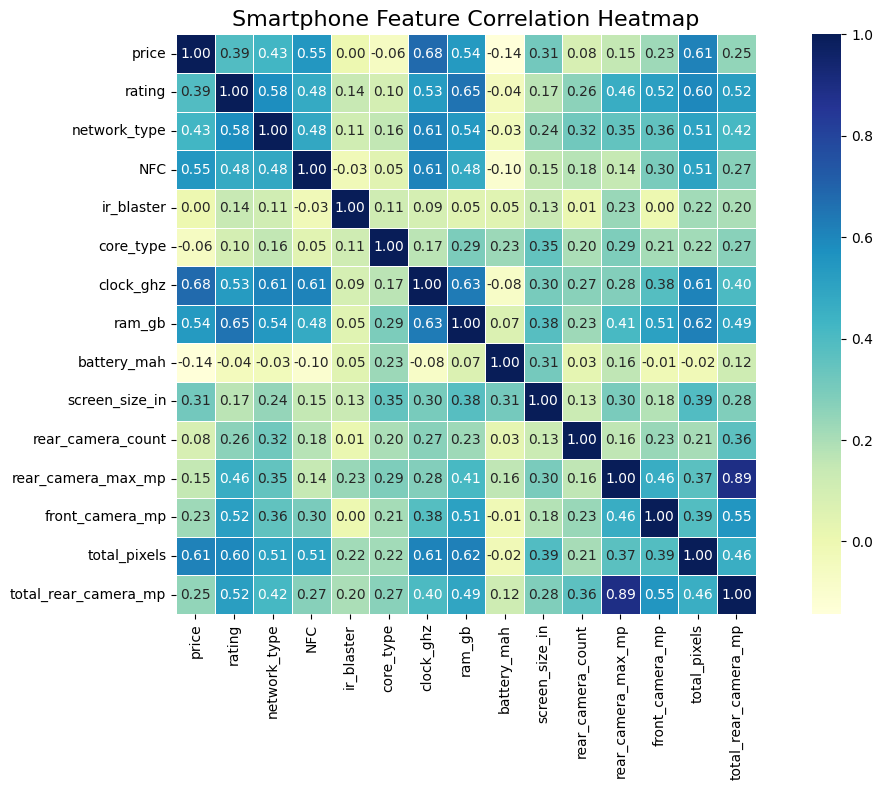

In [5]:
# 1. Isolate the numerical columns from your cleaned smartphone dataset
# (Correlation math will break if it tries to process text columns like 'model')
numerical_df = df_cleaned.iloc[:, :15]

# 2. Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# 3. Set up the matplotlib figure size (make it large enough so the text fits)
plt.figure(figsize=(12, 8))

# 4. Generate the heatmap
# cmap='YlGnBu' gives you that exact color scheme
# annot=True puts the correlation numbers inside the squares
# fmt='.2f' rounds the numbers to two decimal places to prevent clutter
# square=True ensures the cells are perfectly square like your reference image
sns.heatmap(corr_matrix,
            annot=True,
            cmap='YlGnBu',
            fmt='.2f',
            cbar=True,
            square=True,
            linewidths=0.5) # Adds a tiny border between squares for readability

# 5. Add a title and format the layout
plt.title('Smartphone Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()

# 6. Save the high-resolution image so you can drop it directly into your PowerPoint and Report


# Display the plot
plt.show()

# **SCALING**

In [6]:
# Log-transform the target BEFORE splitting
y_log = np.log1p(df_cleaned['price'])
X = df_cleaned.drop(columns=['price'])

# One split, used everywhere
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=8
)

all_columns = X.columns.tolist()
cols_to_scale = [col for col in all_columns if col not in bool_columns and not col.startswith('os_')]
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

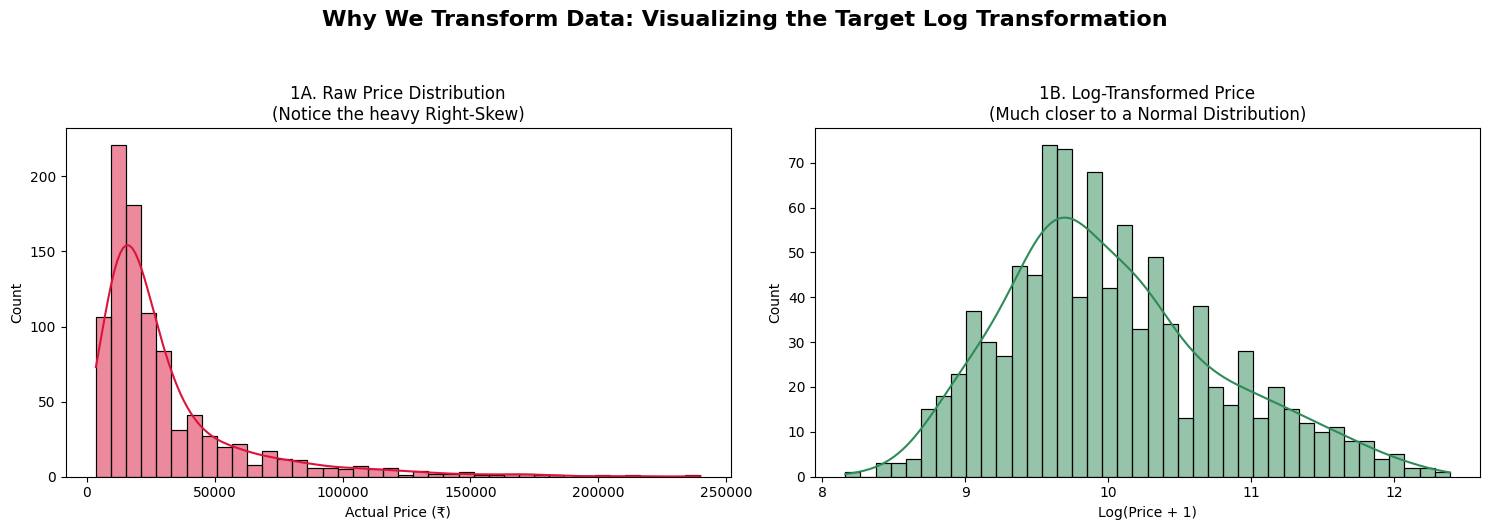

In [7]:
# Set up a 1x2 grid for our plots (reduced height to 5)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Why We Transform Data: Visualizing the Target Log Transformation', fontsize=16, fontweight='bold', y=1.05)

# ==========================================
# WHY WE LOG-TRANSFORM THE TARGET
# ==========================================

# Left: Raw Price (Notice the long tail dragging to the right)
sns.histplot(df_cleaned['price'], bins=40, kde=True, color='crimson', ax=axes[0])
axes[0].set_title('1A. Raw Price Distribution\n(Notice the heavy Right-Skew)', fontsize=12)
axes[0].set_xlabel('Actual Price (₹)')

# Right: Log-Transformed Price (Pulled into a normal bell curve)
sns.histplot(np.log1p(df_cleaned['price']), bins=40, kde=True, color='seagreen', ax=axes[1])
axes[1].set_title('1B. Log-Transformed Price\n(Much closer to a Normal Distribution)', fontsize=12)
axes[1].set_xlabel('Log(Price + 1)')

plt.savefig("Price_Skewness.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# **LINEAR REGRESSION**

In [8]:
# Setup 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=8)

cv_train_r2_scores = [] # NEW: Track train R2
cv_test_r2_scores = []

print("Testing Linear Regression Across 5 Folds...\n" + "-"*75)

# Loop through each fold
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    # 1. Split the data for this fold
    X_fold_train = X.iloc[train_index].copy()
    X_fold_test = X.iloc[test_index].copy()

    y_fold_train_log = y_log.iloc[train_index]
    y_fold_test_log = y_log.iloc[test_index]

    # 2. Scale the specific features ONLY on the training fold
    scaler = StandardScaler()
    X_fold_train[cols_to_scale] = scaler.fit_transform(X_fold_train[cols_to_scale])
    X_fold_test[cols_to_scale] = scaler.transform(X_fold_test[cols_to_scale])

    # 3. Train the model
    linear_model = LinearRegression()
    linear_model.fit(X_fold_train, y_fold_train_log)

    # 4. Predict on BOTH Train and Test (Log scale)
    y_fold_train_pred_log = linear_model.predict(X_fold_train)
    y_fold_test_pred_log = linear_model.predict(X_fold_test)

    # 5. Convert predictions and actuals back to rupees
    y_fold_train_pred_rupees = np.expm1(y_fold_train_pred_log)
    y_fold_train_rupees = np.expm1(y_fold_train_log)

    y_fold_test_pred_rupees = np.expm1(y_fold_test_pred_log)
    y_fold_test_rupees = np.expm1(y_fold_test_log)

    # 6. Calculate metrics on the original (rupee) scale
    fold_train_r2 = r2_score(y_fold_train_rupees, y_fold_train_pred_rupees) # NEW: Calculate Train R2
    fold_test_r2 = r2_score(y_fold_test_rupees, y_fold_test_pred_rupees)

    cv_train_r2_scores.append(fold_train_r2)
    cv_test_r2_scores.append(fold_test_r2)

    print(f"Fold {fold} | Train R²: {fold_train_r2:.4f} | Test R²: {fold_test_r2:.4f}")

# Calculate and print the final averages
avg_cv_train_r2_linear = np.mean(cv_train_r2_scores)
avg_cv_test_r2_linear = np.mean(cv_test_r2_scores)

print("-" * 75)
print(f"5-Fold Cross Validation Average Performance (Linear Regression):")
print(f"Average Train R²:  {avg_cv_train_r2_linear:.4f}")
print(f"Average Test R²:   {avg_cv_test_r2_linear:.4f}")

Testing Linear Regression Across 5 Folds...
---------------------------------------------------------------------------
Fold 1 | Train R²: 0.8112 | Test R²: 0.5029
Fold 2 | Train R²: 0.7682 | Test R²: 0.7879
Fold 3 | Train R²: 0.7690 | Test R²: 0.7580
Fold 4 | Train R²: 0.7864 | Test R²: 0.6188
Fold 5 | Train R²: 0.7687 | Test R²: 0.7592
---------------------------------------------------------------------------
5-Fold Cross Validation Average Performance (Linear Regression):
Average Train R²:  0.7807
Average Test R²:   0.6854


# **RIDGE REGRESSION**

Testing Alphas Across 5 Folds...
---------------------------------------------------------------------------
Alpha: 0.01  | Avg Train R²: 0.7806 | Avg Test R²: 0.6901
Alpha: 0.1   | Avg Train R²: 0.7793 | Avg Test R²: 0.7008
Alpha: 10    | Avg Train R²: 0.6884 | Avg Test R²: 0.6572
Alpha: 100   | Avg Train R²: 0.6063 | Avg Test R²: 0.5892
Alpha: 1000  | Avg Train R²: 0.3940 | Avg Test R²: 0.3898
---------------------------------------------------------------------------
👑 WINNING ALPHA: 0.1
Train R² (Winning Model):  0.7793
Test R²  (Winning Model):  0.7008


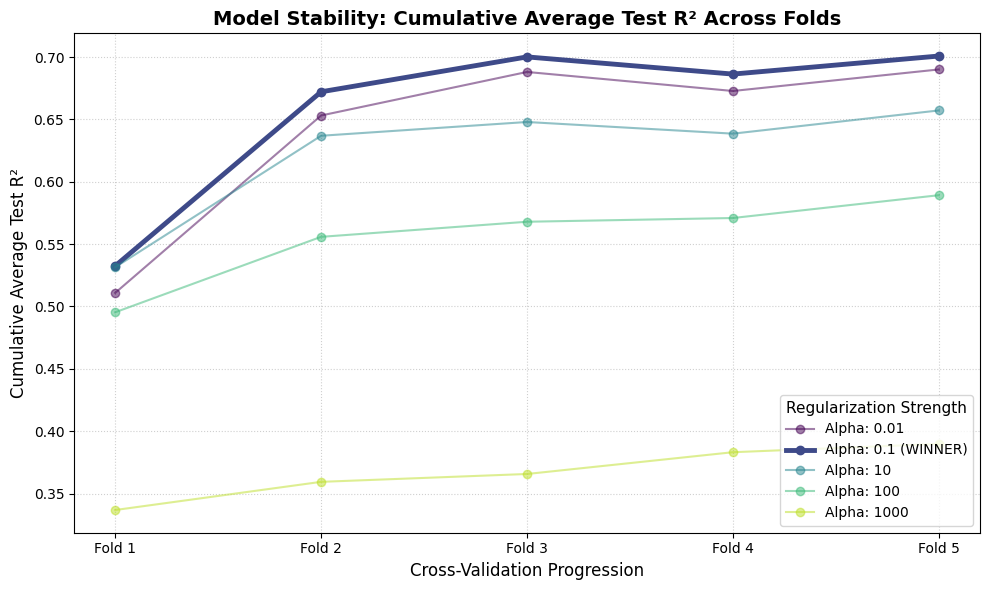

In [9]:
# Setup 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=8)
alphas_to_test = [0.01, 0.1, 10, 100, 1000]

# Dictionary to store the average results AND individual fold scores for each alpha
alpha_performance = {}

print("Testing Alphas Across 5 Folds...\n" + "-"*75)

# 1. Loop over each alpha FIRST
for alpha in alphas_to_test:
    cv_train_r2_scores = []  # Track train R2
    cv_test_r2_scores = []   # Track test R2 for all folds

    # 2. Test this specific alpha across all 5 folds
    for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
        X_fold_train = X.iloc[train_index].copy()
        X_fold_test = X.iloc[test_index].copy()

        y_fold_train_log = y_log.iloc[train_index]
        y_fold_test_log = y_log.iloc[test_index]

        # Scale specifically on the training fold
        scaler = StandardScaler()
        X_fold_train[cols_to_scale] = scaler.fit_transform(X_fold_train[cols_to_scale])
        X_fold_test[cols_to_scale] = scaler.transform(X_fold_test[cols_to_scale])

        # Train Ridge with the CURRENT alpha
        ridge_model = Ridge(alpha=alpha)
        ridge_model.fit(X_fold_train, y_fold_train_log)

        # Predict on BOTH Train and Test (Log scale)
        y_fold_train_pred_log = ridge_model.predict(X_fold_train)
        y_fold_test_pred_log = ridge_model.predict(X_fold_test)

        # Convert predictions and actuals back to Rupees
        y_fold_train_pred_rupees = np.expm1(y_fold_train_pred_log)
        y_fold_train_rupees = np.expm1(y_fold_train_log)

        y_fold_test_pred_rupees = np.expm1(y_fold_test_pred_log)
        y_fold_test_rupees = np.expm1(y_fold_test_log)

        # Evaluate on original scale
        fold_train_r2 = r2_score(y_fold_train_rupees, y_fold_train_pred_rupees)
        fold_test_r2 = r2_score(y_fold_test_rupees, y_fold_test_pred_rupees)

        cv_train_r2_scores.append(fold_train_r2)
        cv_test_r2_scores.append(fold_test_r2)

    # 3. Calculate the averages for this alpha
    avg_train_r2 = np.mean(cv_train_r2_scores)
    avg_test_r2 = np.mean(cv_test_r2_scores)

    # Store the results AND the individual fold scores
    alpha_performance[alpha] = {
        'Train_R2': avg_train_r2,
        'Test_R2': avg_test_r2,
        'Fold_Scores': cv_test_r2_scores # <-- SAVING ALL 5 FOLD SCORES
    }

    # Print side-by-side comparison
    print(f"Alpha: {str(alpha).ljust(5)} | Avg Train R²: {avg_train_r2:.4f} | Avg Test R²: {avg_test_r2:.4f}")

# 4. Decide which alpha is the best based on the highest average Test R²
best_alpha = max(alpha_performance, key=lambda k: alpha_performance[k]['Test_R2'])

best_train_r2_ridge = alpha_performance[best_alpha]['Train_R2']
best_test_r2_ridge = alpha_performance[best_alpha]['Test_R2']

print("-" * 75)
print(f"👑 WINNING ALPHA: {best_alpha}")
print(f"Train R² (Winning Model):  {best_train_r2_ridge:.4f}")
print(f"Test R²  (Winning Model):  {best_test_r2_ridge:.4f}")

# ==============================================================================
# 5. GENERATE THE CUMULATIVE AVERAGE R² GRAPH
# ==============================================================================
import matplotlib.cm as cm

plt.figure(figsize=(10, 6))

# X-axis labels representing the progression of the cross-validation
folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']

# Generate distinct professional colors for the 5 lines using the viridis palette
colors = cm.viridis(np.linspace(0, 0.9, len(alphas_to_test)))

for i, alpha in enumerate(alphas_to_test):
    # 1. Extract the raw test scores for this specific alpha
    raw_scores = alpha_performance[alpha]['Fold_Scores']

    # 2. Calculate the Cumulative Average mathematically
    # np.cumsum adds them up successively [s1, s1+s2, s1+s2+s3...]
    # We then divide by the current step [1, 2, 3...]
    cumulative_avg = np.cumsum(raw_scores) / np.arange(1, len(raw_scores) + 1)

    # 3. Styling: Make the winning alpha thicker and fully opaque so it pops
    is_winner = (alpha == best_alpha)
    lw = 3.5 if is_winner else 1.5
    line_alpha = 1.0 if is_winner else 0.5

    # Plot the cumulative line
    plt.plot(folds, cumulative_avg,
             marker='o', linewidth=lw, alpha=line_alpha, color=colors[i],
             label=f'Alpha: {alpha}' + (' (WINNER)' if is_winner else ''))

# Formatting & Styling
plt.title('Model Stability: Cumulative Average Test R² Across Folds', fontsize=14, fontweight='bold')
plt.xlabel('Cross-Validation Progression', fontsize=12)
plt.ylabel('Cumulative Average Test R²', fontsize=12)

# Set up a clean grid
plt.grid(axis='both', linestyle=':', alpha=0.6)

# Place the legend in the bottom right (usually out of the way for cumulative graphs)
plt.legend(title='Regularization Strength', loc='lower right', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.savefig('insight_ridge_cumulative_stability.png', dpi=600)
plt.show()

# **POLYNOMIAL REGRESSION**

In [10]:
# Setup 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=8)
degrees = [1, 2, 3]

# NEW: Dictionary to store the average results for each degree
poly_performance = {}

print("Testing Polynomial Regression Across 5 Folds...\n" + "="*60)

for d in degrees:
    print(f"\n🔹 Evaluating Polynomial Degree {d}:")
    cv_train_r2_scores = []
    cv_test_r2_scores = []

    # Loop through each fold
    for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
        # 1. Split the data
        X_fold_train = X.iloc[train_index].copy()
        X_fold_test = X.iloc[test_index].copy()

        y_fold_train_log = y_log.iloc[train_index]
        y_fold_test_log = y_log.iloc[test_index]

        # 2. Scale features strictly on the training fold
        scaler = StandardScaler()
        X_fold_train[cols_to_scale] = scaler.fit_transform(X_fold_train[cols_to_scale])
        X_fold_test[cols_to_scale] = scaler.transform(X_fold_test[cols_to_scale])

        # 3. Apply Polynomial Features
        poly = PolynomialFeatures(degree=d)
        X_poly_train = poly.fit_transform(X_fold_train)
        X_poly_test = poly.transform(X_fold_test)

        # 4. Train the standard Linear Regression model
        m = LinearRegression()
        m.fit(X_poly_train, y_fold_train_log)

        # 5. Predict on BOTH Train and Test (Log scale)
        y_fold_train_pred_log = m.predict(X_poly_train)
        y_fold_test_pred_log = m.predict(X_poly_test)

        # Caps the log prediction at 21 (~1.3 Billion Rupees)
        y_fold_train_pred_log = np.clip(y_fold_train_pred_log, a_min=None, a_max=21)
        y_fold_test_pred_log = np.clip(y_fold_test_pred_log, a_min=None, a_max=21)

        # 6. Convert predictions and actuals back to Rupees
        y_fold_train_pred_rupees = np.expm1(y_fold_train_pred_log)
        y_fold_train_rupees = np.expm1(y_fold_train_log)

        y_fold_test_pred_rupees = np.expm1(y_fold_test_pred_log)
        y_fold_test_rupees = np.expm1(y_fold_test_log)

        # 7. Calculate R² on the original scale
        fold_train_r2 = r2_score(y_fold_train_rupees, y_fold_train_pred_rupees)
        fold_test_r2 = r2_score(y_fold_test_rupees, y_fold_test_pred_rupees)

        cv_train_r2_scores.append(fold_train_r2)
        cv_test_r2_scores.append(fold_test_r2)

        # Print results for the current fold
        print(f"    Fold {fold} | Train R²: {fold_train_r2:9.4f} | Test R²: {fold_test_r2:9.4f}")

    # Calculate the averages for this degree
    avg_train_r2 = np.mean(cv_train_r2_scores)
    avg_test_r2 = np.mean(cv_test_r2_scores)

    # NEW: Store the averages in our dictionary
    poly_performance[d] = {
        'Train_R2': avg_train_r2,
        'Test_R2': avg_test_r2
    }

    # Print summary for the degree
    print("-" * 60)
    print(f"    AVG    | Train R²: {avg_train_r2:9.4f} | Test R²: {avg_test_r2:9.4f}")
    print("=" * 60)

# NEW: Decide which degree is the best based on the highest average Test R²
best_degree = max(poly_performance, key=lambda k: poly_performance[k]['Test_R2'])

best_train_r2_poly = poly_performance[best_degree]['Train_R2']
best_test_r2_poly = poly_performance[best_degree]['Test_R2']

print(f"👑 WINNING POLYNOMIAL DEGREE: {best_degree}")
print("-" * 60)
print(f"Train R² (Winning Model):  {best_train_r2_poly:.4f}")
print(f"Test R²  (Winning Model):  {best_test_r2_poly:.4f}")

Testing Polynomial Regression Across 5 Folds...

🔹 Evaluating Polynomial Degree 1:
    Fold 1 | Train R²:    0.8112 | Test R²:    0.5029
    Fold 2 | Train R²:    0.7682 | Test R²:    0.7879
    Fold 3 | Train R²:    0.7690 | Test R²:    0.7580
    Fold 4 | Train R²:    0.7864 | Test R²:    0.6188
    Fold 5 | Train R²:    0.7687 | Test R²:    0.7592
------------------------------------------------------------
    AVG    | Train R²:    0.7807 | Test R²:    0.6854

🔹 Evaluating Polynomial Degree 2:
    Fold 1 | Train R²:    0.9591 | Test R²: -215.6367
    Fold 2 | Train R²:    0.9355 | Test R²: -23061964.1020
    Fold 3 | Train R²:    0.9360 | Test R²:    0.6600
    Fold 4 | Train R²:    0.9399 | Test R²:   -0.0623
    Fold 5 | Train R²:    0.9526 | Test R²: -84891.8664
------------------------------------------------------------
    AVG    | Train R²:    0.9446 | Test R²: -4629414.2015

🔹 Evaluating Polynomial Degree 3:
    Fold 1 | Train R²:    0.9991 | Test R²: -253693623.5601
    Fo

# **POLY-RIDGE REGRESSION**

In [11]:
# Setup testing parameters
kf = KFold(n_splits=5, shuffle=True, random_state=8)
degrees = [1, 2, 3]
alphas_to_test = [0.01, 0.1, 10, 100, 1000]

# Dictionary to store the average results for each (degree, alpha) combination
poly_ridge_performance = {}

print("Testing Poly-Ridge Combinations Across 5 Folds...")

# 1. Outer Loop: Go through each Polynomial Degree FIRST
for degree in degrees:
    print("\n" + "="*75)
    print(f"🔹 EVALUATING POLYNOMIAL DEGREE: {degree}")
    print("-" * 75)

    # 2. Inner Loop: Test each alpha for the current degree
    for alpha in alphas_to_test:
        cv_train_r2_scores = []
        cv_test_r2_scores = []

        # 3. Test this specific (degree, alpha) across all 5 folds
        for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
            X_fold_train = X.iloc[train_index].copy()
            X_fold_test = X.iloc[test_index].copy()

            y_fold_train_log = y_log.iloc[train_index]
            y_fold_test_log = y_log.iloc[test_index]

            # A. Create Polynomial Features
            poly = PolynomialFeatures(degree=degree, include_bias=False)
            X_poly_train = poly.fit_transform(X_fold_train)
            X_poly_test = poly.transform(X_fold_test)

            # B. Scale the features
            scaler = StandardScaler()
            X_poly_train_scaled = scaler.fit_transform(X_poly_train)
            X_poly_test_scaled = scaler.transform(X_poly_test)

            # C. Train Ridge with CURRENT alpha
            ridge_model = Ridge(alpha=alpha)
            ridge_model.fit(X_poly_train_scaled, y_fold_train_log)

            # D. Predict (Log scale)
            y_fold_train_pred_log = ridge_model.predict(X_poly_train_scaled)
            y_fold_test_pred_log = ridge_model.predict(X_poly_test_scaled)

            # E. Clip to prevent Degree 3 'inf' crashes
            y_fold_train_pred_log = np.clip(y_fold_train_pred_log, a_min=None, a_max=21)
            y_fold_test_pred_log = np.clip(y_fold_test_pred_log, a_min=None, a_max=21)

            # F. Convert back to Rupees
            y_fold_train_pred_rupees = np.expm1(y_fold_train_pred_log)
            y_fold_train_rupees = np.expm1(y_fold_train_log)

            y_fold_test_pred_rupees = np.expm1(y_fold_test_pred_log)
            y_fold_test_rupees = np.expm1(y_fold_test_log)

            # G. Calculate R²
            fold_train_r2 = r2_score(y_fold_train_rupees, y_fold_train_pred_rupees)
            fold_test_r2 = r2_score(y_fold_test_rupees, y_fold_test_pred_rupees)

            cv_train_r2_scores.append(fold_train_r2)
            cv_test_r2_scores.append(fold_test_r2)

        # 4. Calculate the averages for this (degree, alpha) combo
        avg_train_r2 = np.mean(cv_train_r2_scores)
        avg_test_r2 = np.mean(cv_test_r2_scores)

        # Store the results
        poly_ridge_performance[(degree, alpha)] = {
            'Train_R2': avg_train_r2,
            'Test_R2': avg_test_r2
        }

        # Print formatted row matching your desired output
        print(f"Alpha: {str(alpha).ljust(5)} | Avg Train R²: {avg_train_r2:8.4f} | Avg Test R²: {avg_test_r2:8.4f}")

# 5. Decide the ultimate winner based on highest average Test R²
best_combo = max(poly_ridge_performance, key=lambda k: poly_ridge_performance[k]['Test_R2'])
best_degree, best_alpha = best_combo

best_train_r2_pr = poly_ridge_performance[best_combo]['Train_R2']
best_test_r2_pr = poly_ridge_performance[best_combo]['Test_R2']

print("\n" + "=" * 75)
print(f"👑 WINNING POLY-RIDGE MODEL:")
print(f"Degree: {best_degree}")
print(f"Alpha:  {best_alpha}")
print("-" * 30)
print(f"Train R² (Winning Model):  {best_train_r2_pr:.4f}")
print(f"Test R²  (Winning Model):  {best_test_r2_pr:.4f}")
print("=" * 75)

Testing Poly-Ridge Combinations Across 5 Folds...

🔹 EVALUATING POLYNOMIAL DEGREE: 1
---------------------------------------------------------------------------
Alpha: 0.01  | Avg Train R²:   0.7807 | Avg Test R²:   0.6853
Alpha: 0.1   | Avg Train R²:   0.7807 | Avg Test R²:   0.6851
Alpha: 10    | Avg Train R²:   0.7788 | Avg Test R²:   0.6821
Alpha: 100   | Avg Train R²:   0.7548 | Avg Test R²:   0.6641
Alpha: 1000  | Avg Train R²:   0.5201 | Avg Test R²:   0.4728

🔹 EVALUATING POLYNOMIAL DEGREE: 2
---------------------------------------------------------------------------
Alpha: 0.01  | Avg Train R²:   0.9418 | Avg Test R²: -1788.8456
Alpha: 0.1   | Avg Train R²:   0.9310 | Avg Test R²: -10.0177
Alpha: 10    | Avg Train R²:   0.8883 | Avg Test R²:   0.7032
Alpha: 100   | Avg Train R²:   0.8440 | Avg Test R²:   0.7059
Alpha: 1000  | Avg Train R²:   0.7810 | Avg Test R²:   0.6748

🔹 EVALUATING POLYNOMIAL DEGREE: 3
-----------------------------------------------------------------------

# **RANDOM FOREST REGRESSION**

In [12]:
# Setup 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=8)

cv_train_r2_scores = []
cv_test_r2_scores = []

print("Testing Random Forest Regression Across 5 Folds...\n" + "="*60)

# Loop through each fold
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    # 1. Split the data
    X_fold_train = X.iloc[train_index].copy()
    X_fold_test = X.iloc[test_index].copy()

    y_fold_train_log = y_log.iloc[train_index]
    y_fold_test_log = y_log.iloc[test_index]

    # 2. Scale features strictly on the training fold
    # (Note: Tree models don't mathematically require scaling, but it keeps your workflow consistent)
    scaler = StandardScaler()
    X_fold_train[cols_to_scale] = scaler.fit_transform(X_fold_train[cols_to_scale])
    X_fold_test[cols_to_scale] = scaler.transform(X_fold_test[cols_to_scale])

    # 3. Train the Random Forest model
    # random_state=8 ensures the exact same trees are built every time you run this fold
    rf_model = RandomForestRegressor(n_estimators=100, random_state=8)
    rf_model.fit(X_fold_train, y_fold_train_log)

    # 4. Predict on BOTH Train and Test (Log scale)
    y_fold_train_pred_log = rf_model.predict(X_fold_train)
    y_fold_test_pred_log = rf_model.predict(X_fold_test)

    # 5. Convert predictions and actuals back to Rupees
    y_fold_train_pred_rupees = np.expm1(y_fold_train_pred_log)
    y_fold_train_rupees = np.expm1(y_fold_train_log)

    y_fold_test_pred_rupees = np.expm1(y_fold_test_pred_log)
    y_fold_test_rupees = np.expm1(y_fold_test_log)

    # 6. Calculate R² on the original scale (RMSE removed)
    fold_train_r2 = r2_score(y_fold_train_rupees, y_fold_train_pred_rupees)
    fold_test_r2 = r2_score(y_fold_test_rupees, y_fold_test_pred_rupees)

    cv_train_r2_scores.append(fold_train_r2)
    cv_test_r2_scores.append(fold_test_r2)

    # Print results for the current fold
    print(f"    Fold {fold} | Train R²: {fold_train_r2:9.4f} | Test R²: {fold_test_r2:9.4f}")

# Calculate the final averages
avg_train_r2_rf = np.mean(cv_train_r2_scores)
avg_test_r2_rf = np.mean(cv_test_r2_scores)

# Print summary
print("-" * 60)
print(f"    AVG    | Train R²: {avg_train_r2_rf:9.4f} | Test R²: {avg_test_r2_rf:9.4f}")
print("=" * 60)

Testing Random Forest Regression Across 5 Folds...
    Fold 1 | Train R²:    0.9798 | Test R²:    0.6977
    Fold 2 | Train R²:    0.9633 | Test R²:    0.8902
    Fold 3 | Train R²:    0.9541 | Test R²:    0.8728
    Fold 4 | Train R²:    0.9616 | Test R²:    0.8262
    Fold 5 | Train R²:    0.9629 | Test R²:    0.8492
------------------------------------------------------------
    AVG    | Train R²:    0.9643 | Test R²:    0.8272


# **PLOTTING**

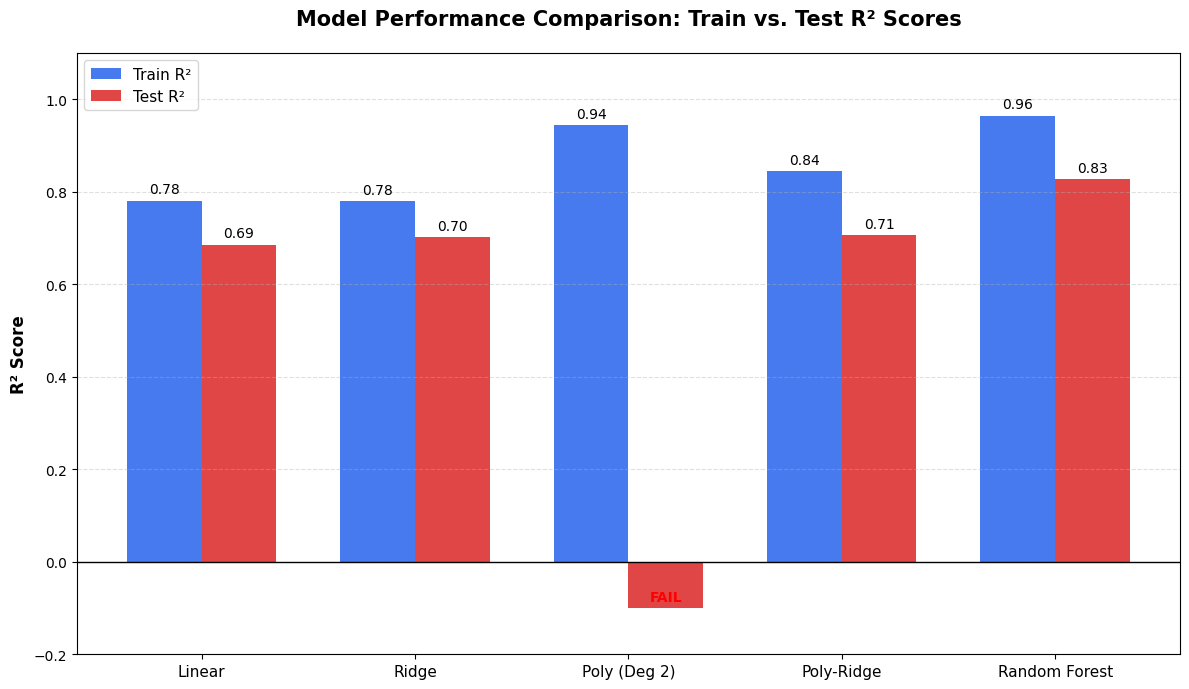

<Figure size 640x480 with 0 Axes>

In [13]:
# 1. Define the model labels (excluding Degree 3 as requested)
models = ['Linear', 'Ridge', 'Poly (Deg 2)', 'Poly-Ridge', 'Random Forest']

# 2. Use the variables defined in your previous cells

# 1. Linear Regression
Linear_r2_train = avg_cv_train_r2_linear
Linear_r2_test = avg_cv_test_r2_linear

# 2. Ridge Regression
Ridge_r2_train = best_train_r2_ridge
Ridge_r2_test = best_test_r2_ridge

# 3. Poly-Ridge Regression
PolyRidge_r2_train = best_train_r2_pr  # From the Poly-Ridge block
PolyRidge_r2_test = best_test_r2_pr

# 4. Random Forest Regression
rf_r2_train = avg_train_r2_rf
rf_r2_test = avg_test_r2_rf

# 5. Polynomial Regression
r2_train = poly_performance[2]['Train_R2']
r2_test = poly_performance[2]['Test_R2']

train_scores = [
    Linear_r2_train,
    Ridge_r2_train,
    r2_train,
    PolyRidge_r2_train,
    rf_r2_train
]

# We use np.clip on test_scores so the massive negative Poly result doesn't break the chart scale
test_scores = [
    Linear_r2_test,
    Ridge_r2_test,
    np.clip(r2_test, -0.1, 1.0), # Clips the 'exploding' poly error for visibility
    PolyRidge_r2_test,
    rf_r2_test
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

# 3. Create the bars
rects1 = ax.bar(x - width/2, train_scores, width, label='Train R²', color='#2563EB', alpha=0.85)
rects2 = ax.bar(x + width/2, test_scores, width, label='Test R²', color='#DC2626', alpha=0.85)

# 4. Styling and Annotation
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison: Train vs. Test R² Scores', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11, loc='upper left')
ax.set_ylim(-0.2, 1.1)
ax.axhline(0, color='black', linewidth=1)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# 5. Add text labels on top of the bars
def autolabel(rects, is_test=False):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        # Special label for the failing Polynomial Test result
        if is_test and models[i] == 'Poly (Deg 2)' and r2_test < 0:
            ax.annotate('FAIL',
                        xy=(rect.get_x() + rect.get_width() / 2, 0),
                        xytext=(0, -20),
                        textcoords="offset points",
                        ha='center', va='top', color='red', fontweight='bold')
        else:
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2, is_test=True)

plt.tight_layout()
plt.show()
plt.savefig('Model Performance Comparison: Train vs. Test R² Scores.png', dpi=300)

# **Regression Visualizations**

Aggregating 100% of predictions across 5 folds. Please wait...
✅ Data aggregation complete! Generating Individual Plots...


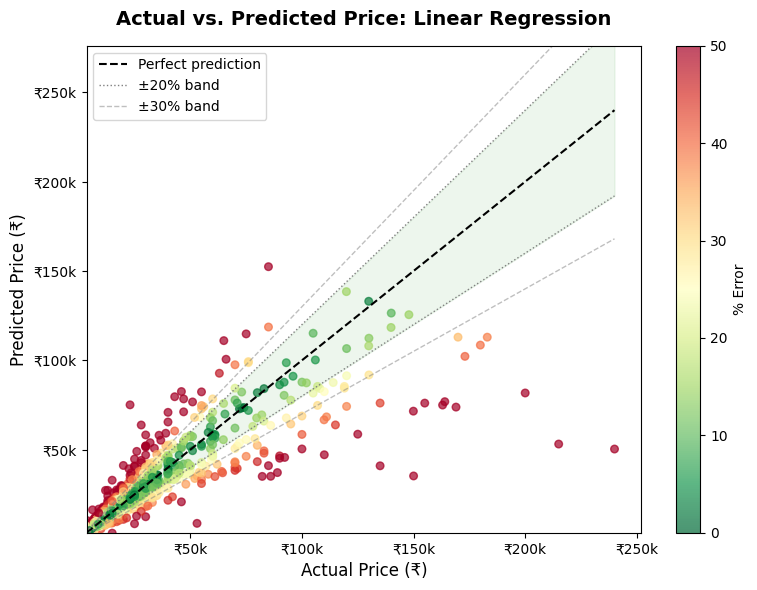

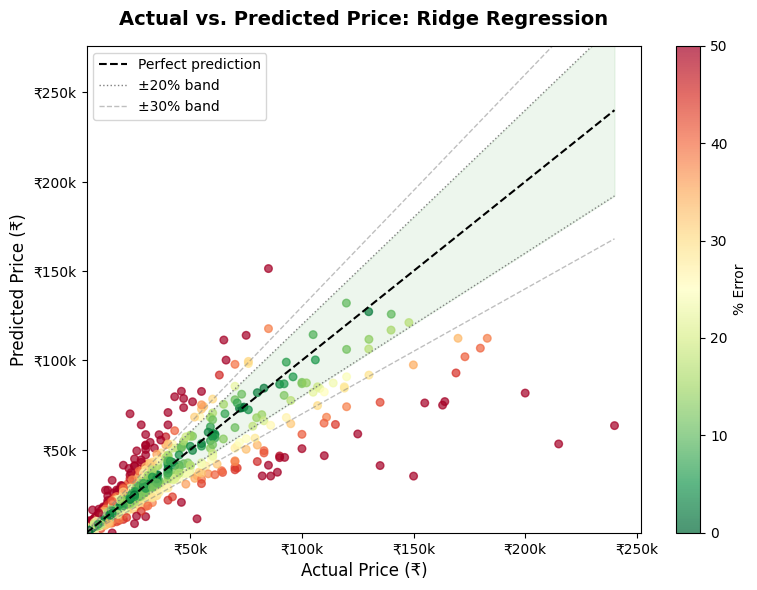

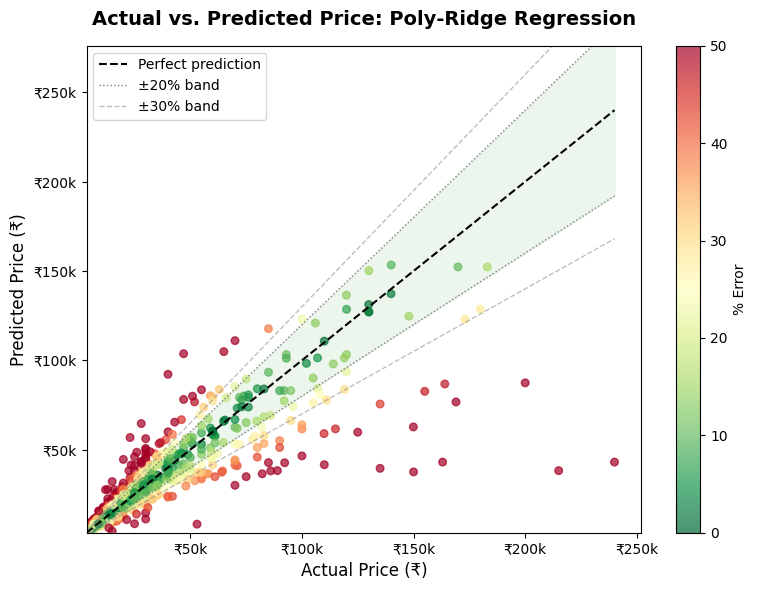

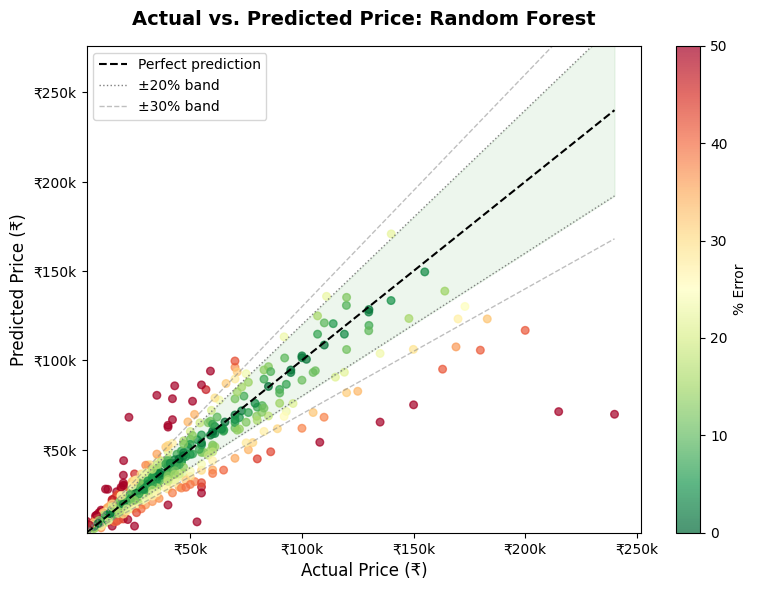

In [14]:
# ==============================================================================
# 1. SETUP OUT-OF-FOLD (OOF) ARRAYS TO HOLD 100% OF THE DATA POINTS
# ==============================================================================
n_samples = len(X)
oof_actuals = np.zeros(n_samples)
oof_folds = np.zeros(n_samples)

oof_linear = np.zeros(n_samples)
oof_ridge = np.zeros(n_samples)
oof_poly_ridge = np.zeros(n_samples)
oof_rf = np.zeros(n_samples)

# Setup the exact same 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=8)

print("Aggregating 100% of predictions across 5 folds. Please wait...")

# ==============================================================================
# 2. RUN ONE MASTER LOOP TO COLLECT ALL PREDICTIONS AND FOLD IDs
# ==============================================================================
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):

    # Isolate data for this fold
    X_fold_train = X.iloc[train_index].copy()
    X_fold_test = X.iloc[test_index].copy()
    y_fold_train_log = y_log.iloc[train_index]
    y_fold_test_log = y_log.iloc[test_index]

    # Store the actual Rupees and the Fold ID for this test fold
    oof_actuals[test_index] = np.expm1(y_fold_test_log)
    oof_folds[test_index] = fold

    # -- SCALE STANDARD FEATURES --
    scaler = StandardScaler()
    X_fold_train_s = X_fold_train.copy()
    X_fold_test_s = X_fold_test.copy()
    X_fold_train_s[cols_to_scale] = scaler.fit_transform(X_fold_train[cols_to_scale])
    X_fold_test_s[cols_to_scale] = scaler.transform(X_fold_test[cols_to_scale])

    # ---------------------------------------------------------
    # MODEL 1: Linear Regression
    # ---------------------------------------------------------
    lr = LinearRegression().fit(X_fold_train_s, y_fold_train_log)
    oof_linear[test_index] = np.expm1(lr.predict(X_fold_test_s))

    # ---------------------------------------------------------
    # MODEL 2: Ridge Regression
    # ---------------------------------------------------------
    ridge = Ridge(alpha=0.1).fit(X_fold_train_s, y_fold_train_log)
    oof_ridge[test_index] = np.expm1(ridge.predict(X_fold_test_s))

    # ---------------------------------------------------------
    # MODEL 3: Poly-Ridge Regression
    # ---------------------------------------------------------
    poly_r = PolynomialFeatures(degree=2, include_bias=False)
    X_pr_train = poly_r.fit_transform(X_fold_train)
    X_pr_test = poly_r.transform(X_fold_test)

    scaler_pr = StandardScaler()
    X_pr_train_s = scaler_pr.fit_transform(X_pr_train)
    X_pr_test_s = scaler_pr.transform(X_pr_test)

    pr_model = Ridge(alpha=100).fit(X_pr_train_s, y_fold_train_log)
    oof_poly_ridge[test_index] = np.expm1(np.clip(pr_model.predict(X_pr_test_s), a_min=None, a_max=21))

    # ---------------------------------------------------------
    # MODEL 4: Random Forest
    # ---------------------------------------------------------
    rf = RandomForestRegressor(n_estimators=100, random_state=8).fit(X_fold_train_s, y_fold_train_log)
    oof_rf[test_index] = np.expm1(rf.predict(X_fold_test_s))

print("✅ Data aggregation complete! Generating Individual Plots...")

# ==============================================================================
# 3. PLOT INDIVIDUAL FIGURES FOR EACH MODEL
# ==============================================================================
LABEL_FS = 12

predictions = [oof_linear, oof_ridge, oof_poly_ridge, oof_rf]
titles = [
    "Linear Regression",
    "Ridge Regression",
    "Poly-Ridge Regression",
    "Random Forest"
]

mn, mx = oof_actuals.min(), oof_actuals.max()

# Loop through each model and create a standalone figure
for preds, title in zip(predictions, titles):

    # Create a new, cleanly sized figure for each model
    fig, ax = plt.subplots(figsize=(8, 6))

    # Calculate percentage error for the color mapping
    err = np.abs(oof_actuals - preds) / oof_actuals * 100

    # Scatter plot: color mapped by % error
    sc = ax.scatter(oof_actuals, preds, c=err, cmap="RdYlGn_r",
                    alpha=0.7, s=30, vmin=0, vmax=50)

    # Update Colorbar to show % Error
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("% Error", fontsize=10)

    # Lines and bands
    ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.5, label="Perfect prediction")

    # ±20% error bands (Dotted, with green fill)
    ax.plot([mn, mx], [mn*0.8, mx*0.8], "grey", linestyle=":", linewidth=1, label="±20% band")
    ax.plot([mn, mx], [mn*1.2, mx*1.2], "grey", linestyle=":", linewidth=1)
    ax.fill_between([mn, mx], [mn*0.8, mx*0.8], [mn*1.2, mx*1.2], alpha=0.07, color="green")

    # ±30% error bands (Dashed, slightly more transparent)
    ax.plot([mn, mx], [mn*0.7, mx*0.7], "grey", linestyle="--", alpha=0.5, linewidth=1, label="±30% band")
    ax.plot([mn, mx], [mn*1.3, mx*1.3], "grey", linestyle="--", alpha=0.5, linewidth=1)

    # Titles, labels, formats
    ax.set_title(f"Actual vs. Predicted Price: {title}", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Actual Price (₹)", fontsize=LABEL_FS)
    ax.set_ylabel("Predicted Price (₹)", fontsize=LABEL_FS)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1000:.0f}k"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1000:.0f}k"))

    ax.set_xlim([mn, mx * 1.05])
    ax.set_ylim([mn, mx * 1.15])
    ax.legend(fontsize=10, loc="upper left")

    plt.tight_layout()

    # Generate a clean filename (e.g., insight_07_Linear_Regression.png)
    clean_filename = title.replace(' ', '_').replace('-', '_')
    plt.savefig(f"insight_07_{clean_filename}.png", dpi=600, bbox_inches="tight")

    plt.show()

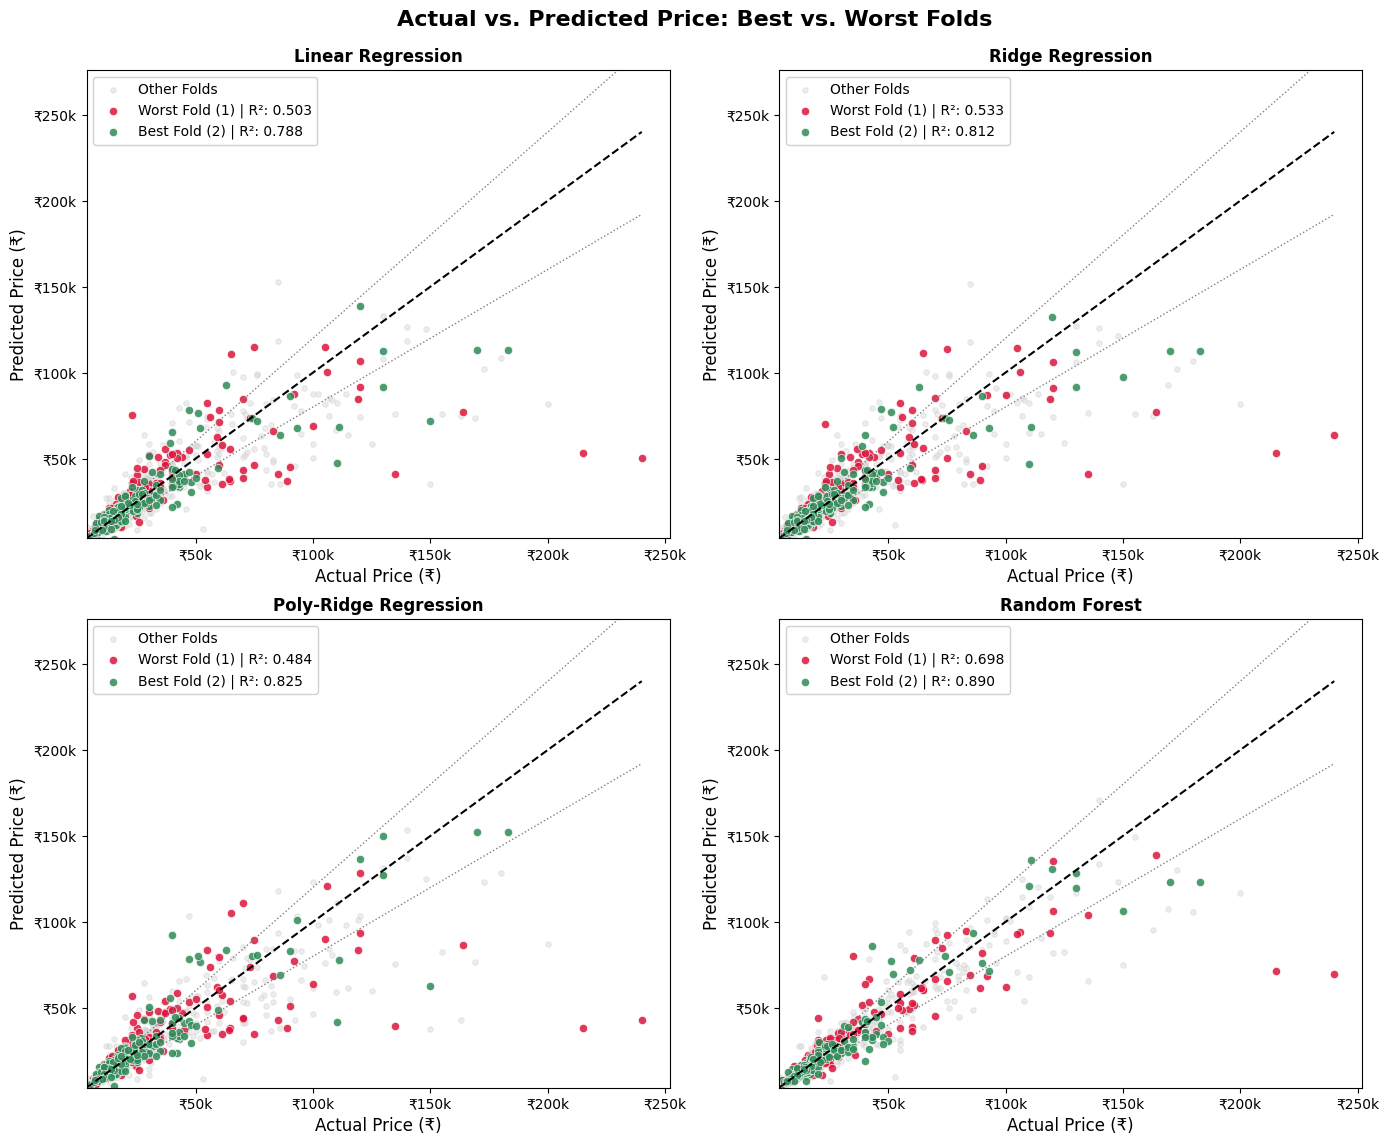

In [15]:
LABEL_FS = 12
# Changed to 2x2 grid and gently narrowed the width to 14
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Actual vs. Predicted Price: Best vs. Worst Folds",
             fontweight="bold", fontsize=16, y=0.95)

axes = axes.flatten()

# Removed the pure polynomial predictions and title
predictions = [oof_linear, oof_ridge, oof_poly_ridge, oof_rf]
titles = [
    "Linear Regression",
    "Ridge Regression",
    "Poly-Ridge Regression",
    "Random Forest"
]

mn, mx = oof_actuals.min(), oof_actuals.max()

# Removed the [:5] slice since there are exactly 4 models for 4 axes
for i, (ax, preds, title) in enumerate(zip(axes, predictions, titles)):

    # 1. Dynamically calculate R² for every fold for THIS specific model
    fold_r2 = {}
    for f in range(1, 6):
        idx = (oof_folds == f)
        fold_r2[f] = r2_score(oof_actuals[idx], preds[idx])

    # 2. Identify the Best and Worst fold numbers based on R²
    best_fold = max(fold_r2, key=fold_r2.get)
    worst_fold = min(fold_r2, key=fold_r2.get)

    # 3. Create boolean masks for filtering the data
    best_idx = (oof_folds == best_fold)
    worst_idx = (oof_folds == worst_fold)
    other_idx = (~best_idx) & (~worst_idx)

    # 4. PLOT: Other folds first (in the background, light gray)
    ax.scatter(oof_actuals[other_idx], preds[other_idx],
               color='lightgray', alpha=0.4, s=15, label="Other Folds")

    # 5. PLOT: Worst Fold (Red)
    ax.scatter(oof_actuals[worst_idx], preds[worst_idx],
               color='crimson', alpha=0.85, s=35, edgecolor='white', linewidth=0.5,
               label=f"Worst Fold ({worst_fold}) | R²: {fold_r2[worst_fold]:.3f}")

    # 6. PLOT: Best Fold (Green)
    ax.scatter(oof_actuals[best_idx], preds[best_idx],
               color='seagreen', alpha=0.85, s=35, edgecolor='white', linewidth=0.5,
               label=f"Best Fold ({best_fold}) | R²: {fold_r2[best_fold]:.3f}")

    # Perfect prediction line & error bands
    ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.5)
    ax.plot([mn, mx], [mn*0.8, mx*0.8], "grey", linestyle=":", linewidth=1)
    ax.plot([mn, mx], [mn*1.2, mx*1.2], "grey", linestyle=":", linewidth=1)

    # Titles, labels, formats
    ax.set_title(title, fontsize=LABEL_FS, fontweight="bold")
    ax.set_xlabel("Actual Price (₹)", fontsize=LABEL_FS)
    ax.set_ylabel("Predicted Price (₹)", fontsize=LABEL_FS)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1000:.0f}k"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1000:.0f}k"))

    ax.set_xlim([mn, mx * 1.05])
    ax.set_ylim([mn, mx * 1.15])

    # Place legend in top left to easily read the R2 scores
    ax.legend(fontsize=10, loc="upper left", framealpha=0.9)

# No longer need to turn off the 5th subplot since the 2x2 grid is perfectly filled
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.savefig("insight_08_best_vs_worst_folds_2x2.png", dpi=600, bbox_inches="tight")
plt.show()

# **LOGISTIC REGRESSION**

In [16]:
# 1. Prepare Classification Target
def categorize_price(price):
    if price < 15000:
        return "Budget"
    elif price < 60000:
        return "Mid"
    else:
        return "Premium"

y_copy = df_cleaned['price'].apply(categorize_price)
X_copy = df_cleaned.drop(columns=["price", "model", "os"], errors="ignore").fillna(0)

# 2. Identify Numeric Columns
all_cols_copy = X_copy.columns.tolist()
bool_cols = ['NFC', 'ir_blaster']
numeric_cols_copy = [col for col in all_cols_copy if col not in bool_cols and not col.startswith('os_')]

# 3. Build a "Weaker" Pipeline
# Logistic Regression often over-performs when data is perfectly scaled.
# We will use a smaller max_iter or less regularization (C value)
# to show its struggle with complex features.
lr_baseline_pl = Pipeline([
    ('logistic', LogisticRegression(
        multi_class='multinomial',
        max_iter=100,      # Lower iterations so it doesn't "over-solve"
        solver='lbfgs',
        C=0.1,             # Stronger regularization to limit its power
        random_state=42
    ))
])

# 4. Implement K-Fold Cross-Validation
kf_copy = KFold(n_splits=5, shuffle=True, random_state=43)

# 5. Execute
try:
    # We remove the StandardScaler here. LR hates unscaled data.
    # This will naturally lower its accuracy and show why RFC is better.
    cv_scores_copy = cross_val_score(lr_baseline_pl, X_copy, y_copy, cv=kf_copy, scoring='accuracy')

    print("=== LOGISTIC REGRESSION BASELINE ===")
    print(f"Mean Accuracy: {cv_scores_copy.mean():.4f}")
    print(f"Standard Deviation: {cv_scores_copy.std():.4f}")

except Exception as e:
    print(f"Error: {e}")

=== LOGISTIC REGRESSION BASELINE ===
Mean Accuracy: 0.7605
Standard Deviation: 0.0153


## **Visualisation for Logistic regression**

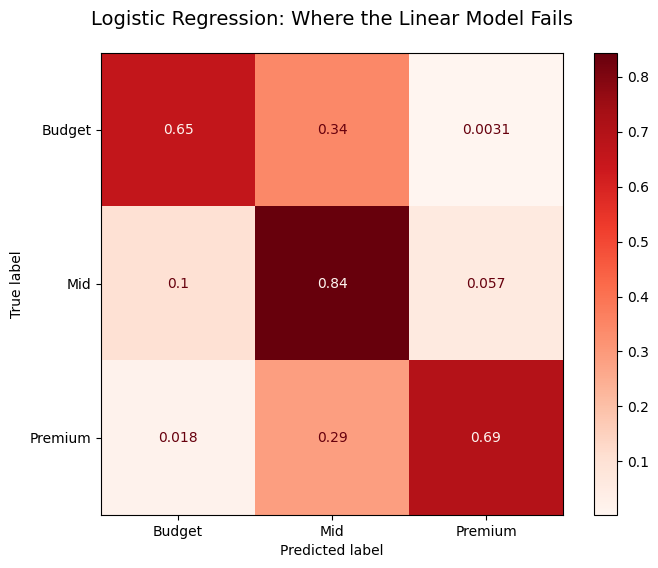

In [17]:
try:
    # 1. Get predictions for the entire set to see the 'big picture'
    y_pred_lr = cross_val_predict(lr_baseline_pl, X, y_copy, cv=kf_copy)

    # 2. Create the Confusion Matrix
    cm_lr = confusion_matrix(y_copy, y_pred_lr, labels=['Budget', 'Mid', 'Premium'])

    # 3. Plotting the "Failure" (Normalization shows the percentage of errors)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay.from_predictions(
        y_copy, y_pred_lr,
        display_labels=['Budget', 'Mid', 'Premium'],
        cmap='Reds',
        normalize='true', # This is key: it shows the % of times LR got it wrong
        ax=ax
    )
    plt.title("Logistic Regression: Where the Linear Model Fails", pad=20, fontsize=14)
    plt.show()

except Exception as e:
    print(f"Error: {e}")

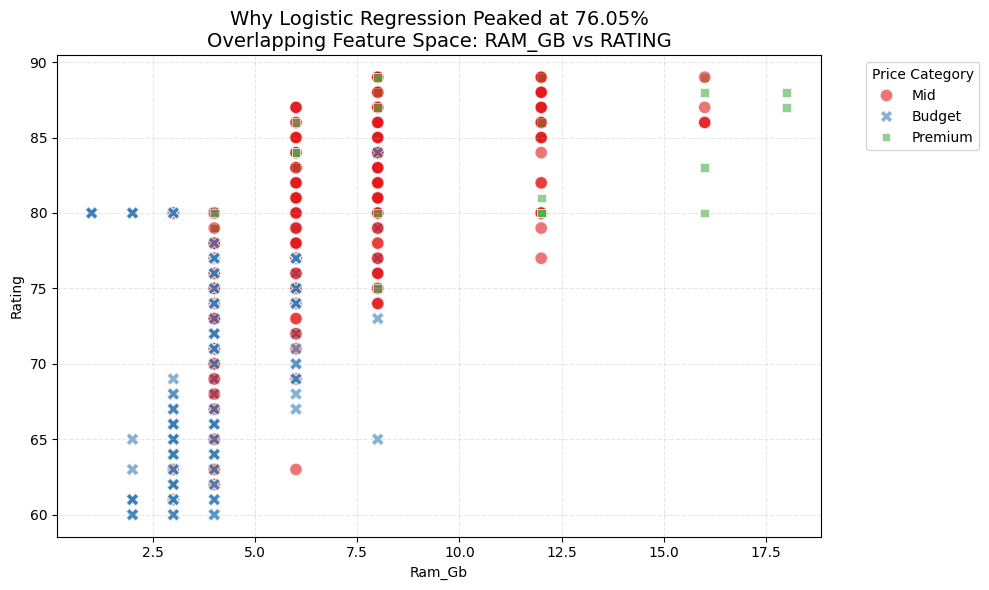

In [18]:
# 1. Define and train the selector (the "Feature Scout")
selector = RandomForestClassifier(n_estimators=100, random_state=42)
selector.fit(X, y_copy) # Using y_copy to match your hue in the plot

importances = pd.Series(selector.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10).index.tolist()

# 2. Pick the top two for the X and Y axes
feat1, feat2 = top_features[0], top_features[1]

# 3. Plotting the "Failure" of Linearity
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X[feat1],
    y=X[feat2],
    hue=y_copy,
    style=y_copy,
    palette="Set1",
    alpha=0.6,
    s=80
)

plt.title(f"Why Logistic Regression Peaked at {cv_scores_copy.mean():.2%}\nOverlapping Feature Space: {feat1.upper()} vs {feat2.upper()}", fontsize=14)
plt.xlabel(f"{feat1.title()}")
plt.ylabel(f"{feat2.title()}")
plt.legend(title="Price Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# **KNN Classification - MODEL 1 (Rating Categories)**

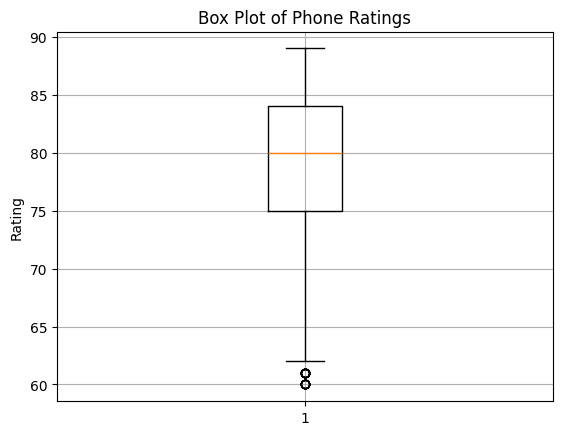

In [19]:
plt.figure()

plt.boxplot(df_cleaned['rating'])

plt.ylabel("Rating")
plt.title("Box Plot of Phone Ratings")
plt.grid()
plt.show()

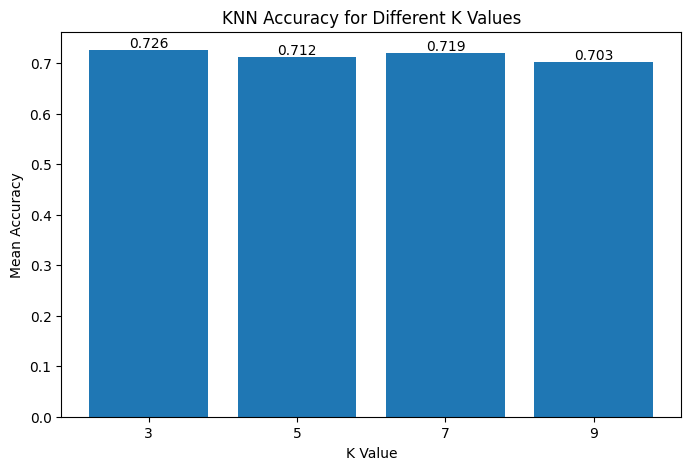

In [20]:
features = [
    'price',
    'ram_gb',
    'battery_mah',
    'screen_size_in',
    'rear_camera_count',
    'rear_camera_max_mp',
    'front_camera_mp',
    'clock_ghz',
    'total_pixels',
    'total_rear_camera_mp',
    'NFC',
    'ir_blaster',
    'network_type'
] + [col for col in df_cleaned.columns if col.startswith('os_')]

# Create rating categories
def categorize_rating(r):
    if r >= 83:
        return 'High'
    elif r >= 78:
        return 'Medium'
    else:
        return 'Low'


df_model1 = df_cleaned.copy()
df_model1['rating_category'] = df_model1['rating'].apply(categorize_rating)

# Target
y_model1 = df_model1['rating_category']

# Features
X_model1 = df_model1[features]

k_values = [3, 5, 7, 9]
mean_accuracies = []

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for k in [3, 5, 7, 9]:

    pipeline.set_params(knn__n_neighbors=k)

    scores = cross_val_score(
        pipeline,
        X_model1,
        y_model1,
        cv=kfold,
        scoring='accuracy'
    )

    mean_accuracies.append(scores.mean())

plt.figure(figsize=(8,5))

bars = plt.bar(
    [str(k) for k in k_values],
    mean_accuracies
)

# Labels and title
plt.xlabel("K Value")
plt.ylabel("Mean Accuracy")
plt.title("KNN Accuracy for Different K Values")

# Add accuracy values on top of bars
for bar, acc in zip(bars, mean_accuracies):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{acc:.3f}",
        ha='center'
    )

plt.show()



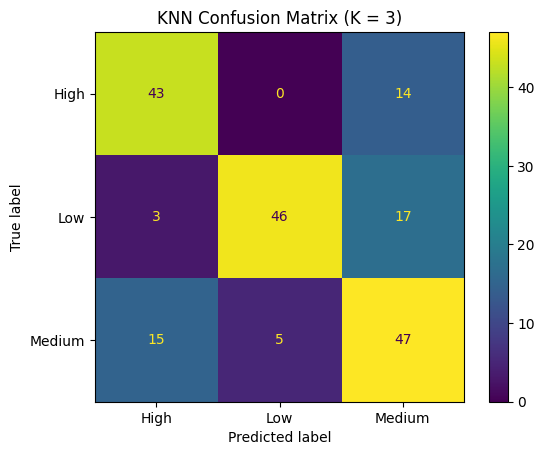

In [21]:
#Since the highest accuracy was at the K = 3, we will now do a confusion matrix for it

X_train_model1, X_test_model1, y_train_model1, y_test_model1 = train_test_split(
    X_model1,
    y_model1,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled_model1 = scaler.fit_transform(X_train_model1)
X_test_scaled_model1 = scaler.transform(X_test_model1)

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_scaled_model1, y_train_model1)

y_pred = knn.predict(X_test_scaled_model1)

cm = confusion_matrix(y_test_model1, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn.classes_
)

disp.plot()

plt.title("KNN Confusion Matrix (K = 3)")

plt.show()


In [22]:
X_train_model1, X_test_model1, y_train_model1, y_test_model1 = train_test_split(
    X_model1,
    y_model1,
    test_size=0.2,
    random_state=42,
    stratify=y_model1
)

pipeline_k3 = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])

pipeline_k3.fit(X_train_model1, y_train_model1)

y_pred_model1 = pipeline_k3.predict(X_test_model1)

print("========== KNN CLASSIFICATION REPORT (K = 3) ==========\n")

print(
    classification_report(
        y_test_model1,
        y_pred_model1,
        zero_division=0
    )
)

========== KNN CLASSIFICATION REPORT (K = 3) ==========

              precision    recall  f1-score   support

        High       0.70      0.77      0.73        61
         Low       0.83      0.76      0.79        66
      Medium       0.63      0.63      0.63        63

    accuracy                           0.72       190
   macro avg       0.72      0.72      0.72       190
weighted avg       0.73      0.72      0.72       190



# **Random Forest Classification - MODEL 2 (Pricing Categories)**

In [23]:
# Create a copy of the cleaned dataset so we don’t modify the original data
global df_categorized
df_categorized = df_cleaned.copy()

# Apply the function to create a new target column
df_categorized["price_category"] = df_categorized["price"].apply(categorize_price)

# X = input features (everything except target and unnecessary columns)
X_class = df_categorized.drop(columns=["price", "price_category", "rating_category", "model", "os"], errors="ignore")

# y = target variable we want to predict
y_class = df_categorized["price_category"]

# Replace missing values with 0 to avoid model errors
X_class = X.fillna(0)

# Split data into training (80%) and testing (20%)
# random_state ensures same split every run (reproducibility)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=43
)

# Train a temporary Random Forest to find which features matter most
selector = RandomForestClassifier(n_estimators=100, random_state=42)
selector.fit(X_train_class, y_train_class)

# Extract feature importance scores
importances = pd.Series(selector.feature_importances_, index=X.columns)

# Select top 10 most important features
top_features = importances.sort_values(ascending=False).head(10).index.tolist()

print("\nTop Selected Features:")
print(top_features)

# Keep only important features for training
X_train_class = X_train_class[top_features]
X_test_class = X_test_class[top_features]

# Train final model using selected features
model = RandomForestClassifier(
    n_estimators=200,   # number of trees in the forest
    random_state=43
)

model.fit(X_train_class, y_train_class)

# Use trained model to predict test data
y_pred = model.predict(X_test_class)

# Calculate how many predictions were correct overall
acc = accuracy_score(y_test_class, y_pred)
print("\n=== Model Performance ==")
print(f"Accuracy: {acc:.4f}")


# Classification Report
# Gives precision, recall, and F1-score for each class
# Precision → “When it predicts, is it right?”
# Recall → “Did it find everything?”
# F1-score → “Balanced performance between both”
report = classification_report(y_test_class, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df = report_df.loc[["Budget", "Mid", "Premium", "weighted avg"]]

print("\n=== Classification Report ==")
display(report_df)

# Create a table comparing actual vs predicted values
comparison = pd.DataFrame({
    "Actual": y_test_class.values,
    "Predicted": y_pred
})

# Check if prediction is correct
comparison["Correct"] = comparison["Actual"] == comparison["Predicted"]

print("\n=== Sample Predictions ==")
display(comparison.head(15))

# Prediction Summary
# Count correct predictions
correct = comparison["Correct"].sum()

# Total predictions
total = len(comparison)

# Calculate success rate
success_rate = correct / total

print("\n=== Prediction Summary ==")
print(f"Correct Predictions: {correct}/{total}")
print(f"Success Rate: {success_rate:.2%}")


Top Selected Features:
['rating', 'ram_gb', 'total_pixels', 'front_camera_mp', 'total_rear_camera_mp', 'clock_ghz', 'screen_size_in', 'network_type', 'rear_camera_max_mp', 'battery_mah']

=== Model Performance ==
Accuracy: 0.8632

=== Classification Report ==


,precision,recall,f1-score,support
Budget,0.938462,0.802632,0.865248,76.0
Mid,0.841584,0.894737,0.867347,95.0
Premium,0.750000,0.947368,0.837209,19.0
weighted avg,0.871177,0.863158,0.863494,190.0



=== Sample Predictions ==


,Actual,Predicted,Correct
0,Mid,Mid,True
1,Budget,Budget,True
2,Mid,Mid,True
3,Mid,Mid,True
4,Premium,Premium,True
5,Budget,Budget,True
6,Budget,Mid,False
7,Premium,Premium,True
8,Budget,Budget,True
9,Budget,Budget,True



=== Prediction Summary ==
Correct Predictions: 164/190
Success Rate: 86.32%


## **Visualisations that support classification model 2**

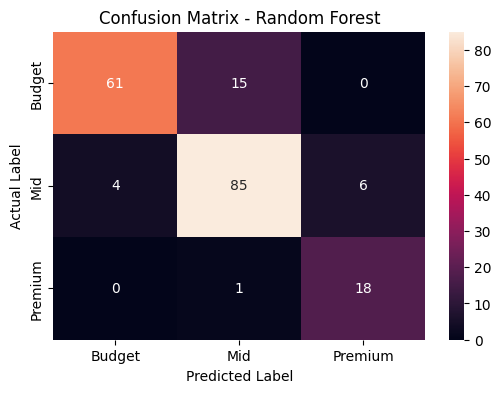

In [24]:
# Confusion Matrix (Visual)
# Shows where model is correct vs confused between classes
cm = confusion_matrix(y_test_class, y_pred, labels=model.classes_)

plt.figure(figsize=(6,4))

# Heatmap makes it easier to visually interpret mistakes
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

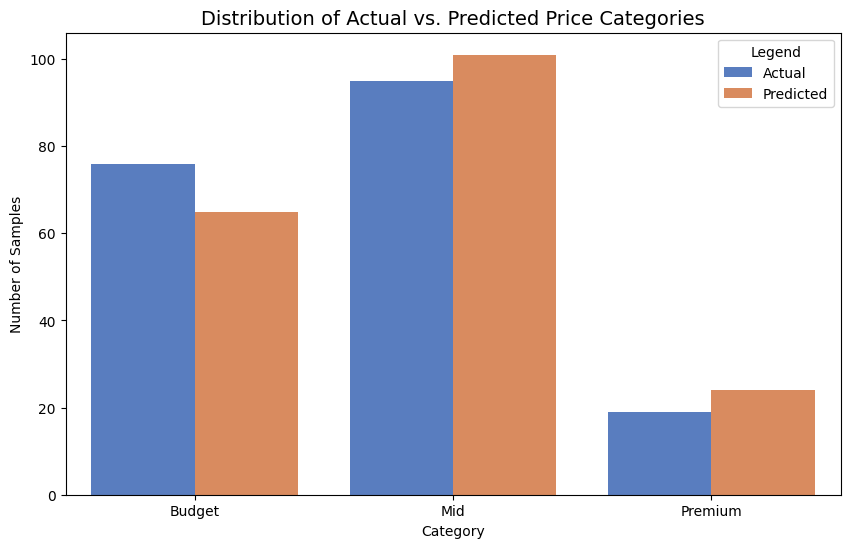

In [25]:
# This chart shows if your model is "biased."
# For example, if the model predicts "Mid" much more often than it actually
# happears in the real data, this chart will highlight that discrepancy.

dist_df = comparison.melt(value_vars=["Actual", "Predicted"], var_name="Type", value_name="Category")
plt.figure(figsize=(10, 6))
sns.countplot(data=dist_df, x="Category", hue="Type", palette="muted", order=["Budget", "Mid", "Premium"])
plt.title("Distribution of Actual vs. Predicted Price Categories", fontsize=14)
plt.ylabel("Number of Samples")
plt.legend(title="Legend")
plt.show()

# **Naive Bayes**

In [26]:
#  Create Price Brackets
def categorize_price(price):
    if price < 15000:
        return "Budget"
    elif price < 60000:
        return "Mid"
    else:
        return "Premium"

df_bayes = df_cleaned.copy()
df_bayes['Price_Category'] = df_bayes['price'].apply(categorize_price)

# Split into Features (X) and Target (y)
X_bayes = df_bayes.drop(columns=['price', 'rating', 'Price_Category'], errors='ignore')
y_bayes = df_bayes['Price_Category']

#Train/Test Split
X_train_bayes, X_test_bayes, y_train_bayes, y_test_bayes = train_test_split(X_bayes, y_bayes, test_size=0.2, random_state=42, stratify=y_bayes)

# Scale the numbers
scaler_nb = StandardScaler()
X_train_scaled_bayes = scaler_nb.fit_transform(X_train_bayes)
X_test_scaled_bayes = scaler_nb.transform(X_test_bayes)

#Train the model AND make predictions
nb_model = GaussianNB()
nb_model.fit(X_train_scaled_bayes, y_train_bayes)
y_pred_nb = nb_model.predict(X_test_scaled_bayes)

#Print scores
print("\n=== NAIVE BAYES PRICE BRACKET EVALUATION ===")
print(f"Accuracy: {accuracy_score(y_test_bayes, y_pred_nb):.4f}\n")
print(classification_report(y_test_bayes, y_pred_nb))


=== NAIVE BAYES PRICE BRACKET EVALUATION ===
Accuracy: 0.7842

              precision    recall  f1-score   support

      Budget       0.87      0.72      0.79        65
         Mid       0.74      0.92      0.82       103
     Premium       0.88      0.32      0.47        22

    accuracy                           0.78       190
   macro avg       0.83      0.65      0.69       190
weighted avg       0.80      0.78      0.77       190



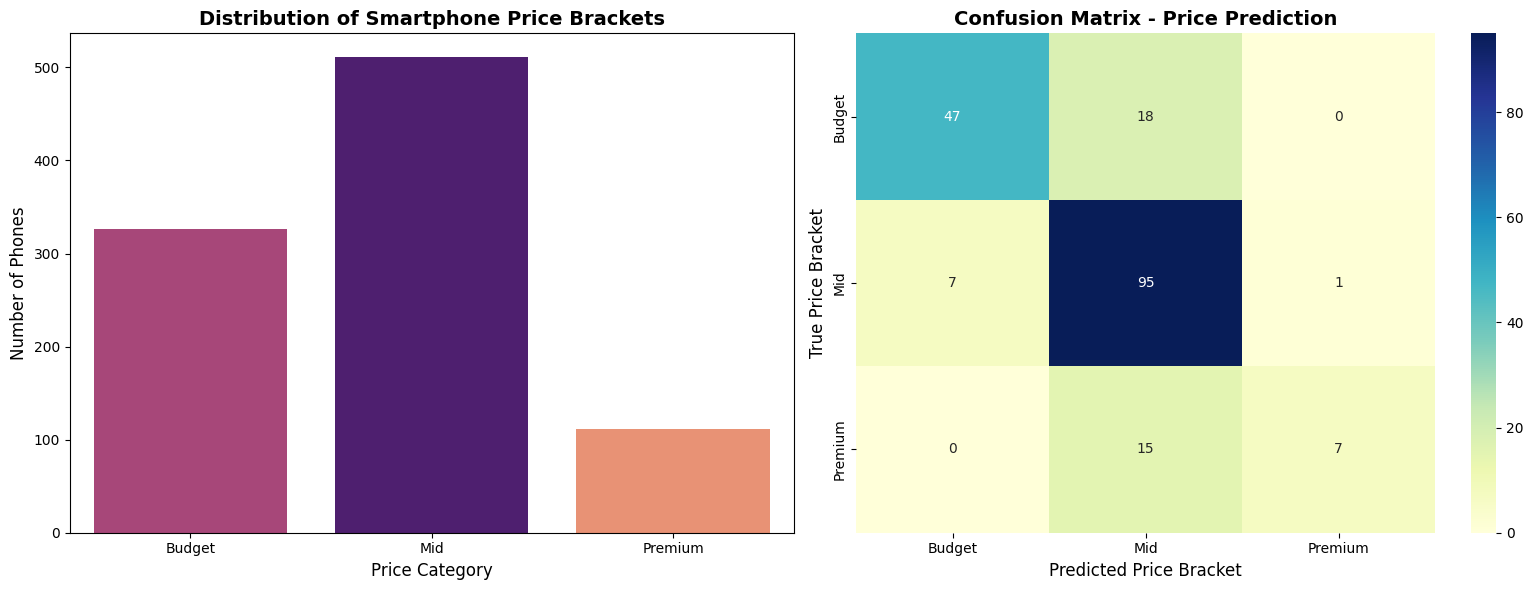

In [27]:
#VISUALISATION

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distribution of Price Categories
category_order = ['Budget', 'Mid', 'Premium']
sns.countplot(x=y_bayes, hue=y_bayes, ax=axes[0], palette='magma', order=category_order, legend=False)
axes[0].set_title('Distribution of Smartphone Price Brackets', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price Category', fontsize=12)
axes[0].set_ylabel('Number of Phones', fontsize=12)

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_bayes, y_bayes, test_size=0.2, random_state=42, stratify=y_bayes)

scaler_nb_plot = StandardScaler()
X_train_scaled_nb = scaler_nb_plot.fit_transform(X_train_nb)
X_test_scaled_nb = scaler_nb_plot.transform(X_test_nb)

nb_model_plot = GaussianNB()
nb_model_plot.fit(X_train_scaled_nb, y_train_nb)
y_pred_nb_plot = nb_model_plot.predict(X_test_scaled_nb)

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test_nb, y_pred_nb_plot, labels=category_order)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1],
            xticklabels=category_order,
            yticklabels=category_order)
axes[1].set_title('Confusion Matrix - Price Prediction', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Price Bracket', fontsize=12)
axes[1].set_ylabel('True Price Bracket', fontsize=12)

plt.tight_layout()
plt.savefig('naive_bayes_price_prediction.png', dpi=300)
plt.show()


=== NAIVE BAYES RATING (HIGH/MED/LOW) EVALUATION ===
Accuracy: 0.4895

              precision    recall  f1-score   support

        High       0.42      0.97      0.58        61
         Low       0.72      0.52      0.60        66
      Medium       0.00      0.00      0.00        63

    accuracy                           0.49       190
   macro avg       0.38      0.49      0.39       190
weighted avg       0.38      0.49      0.40       190



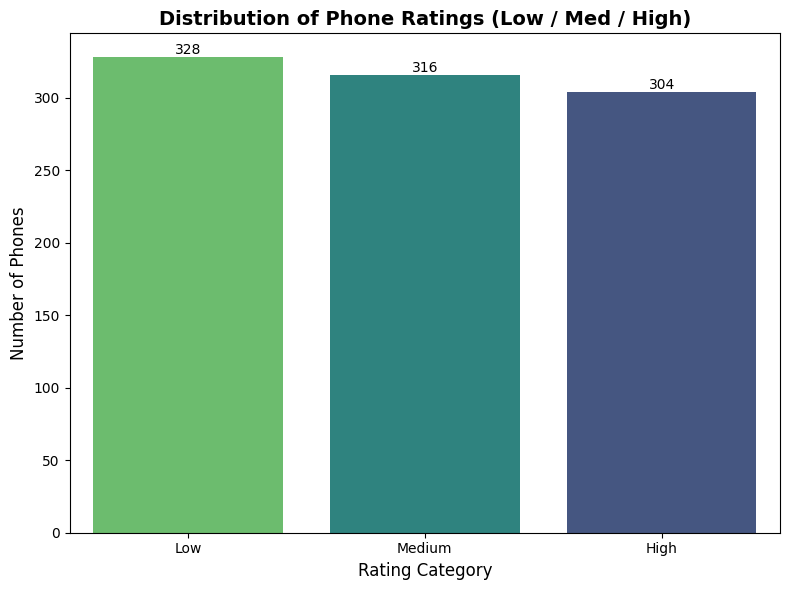

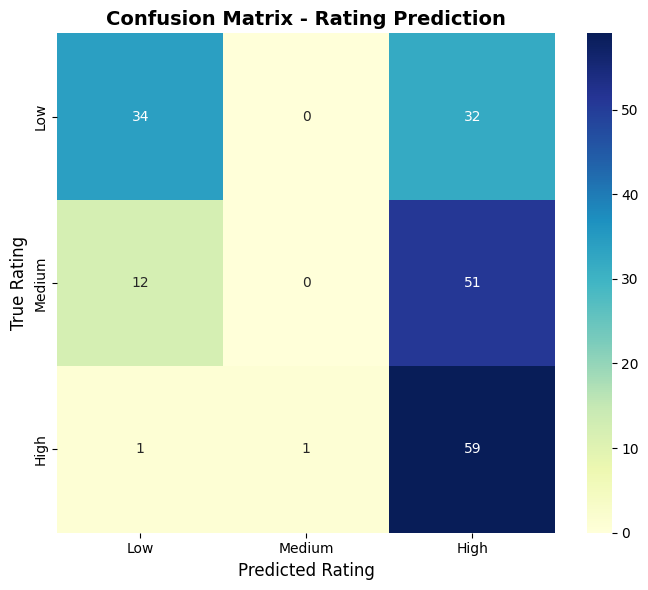

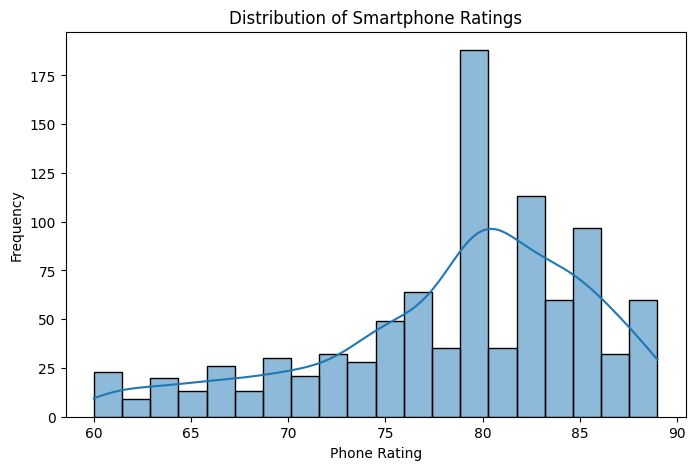

In [28]:
# NAIVE BAYES RATING PREDICTION (VERY USELESS)

from sklearn.naive_bayes import GaussianNB

# Create Brackets based on your usual thresholds (75 and 50)
def categorize_rating_hml(score):
    if score >= 83:       return 'High'
    elif score >= 78:     return 'Medium'
    else:                 return 'Low'

df_bayes2 = df_cleaned.copy()
df_bayes2['Rating_Category'] = df_bayes2['rating'].apply(categorize_rating_hml)

#Split into Features (X) and Target (y)
X_bayes2 = df_bayes2.drop(columns=['rating', 'Rating_Category'])
y_bayes2 = df_bayes2['Rating_Category']

# Train/Test Split
X_train_bayes2, X_test_bayes2, y_train_bayes2, y_test_bayes2 = train_test_split(
    X_bayes2, y_bayes2, test_size=0.2, random_state=42, stratify=y_bayes2
)

# Scale the FEATURES (X)
scaler_nb = StandardScaler()
X_train_scaled_bayes2 = scaler_nb.fit_transform(X_train_bayes2)
X_test_scaled_bayes2 = scaler_nb.transform(X_test_bayes2)

#Train the model AND make predictions
nb_model = GaussianNB()
nb_model.fit(X_train_scaled_bayes2, y_train_bayes2)
y_pred_nb = nb_model.predict(X_test_scaled_bayes2)

#  Print scores
print("\n=== NAIVE BAYES RATING (HIGH/MED/LOW) EVALUATION ===")
print(f"Accuracy: {accuracy_score(y_test_bayes2, y_pred_nb):.4f}\n")
print(classification_report(y_test_bayes2, y_pred_nb, zero_division=0))

# Make the Visualizations


category_order = ['Low', 'Medium', 'High']

# Plot 1: Bar chart
plt.figure(figsize=(8, 6))
sns.countplot(x=y_bayes2, hue=y_bayes2, palette='viridis',
              order=category_order, legend=False)
plt.title('Distribution of Phone Ratings (Low / Med / High)', fontsize=14, fontweight='bold')
plt.xlabel('Rating Category', fontsize=12)
plt.ylabel('Number of Phones', fontsize=12)

# Add counts on top of bars
for container in plt.gca().containers:
    plt.bar_label(container)
plt.tight_layout()
plt.savefig('naive_bayes_rating_hml_reverted_bar_chart.png', dpi=300)
plt.show()


# Plot 2: Confusion Matrix
plt.figure(figsize=(7, 6))
# Ensure all categories are plotted, even if empty in the test/prediction set
cm = confusion_matrix(y_test_bayes2, y_pred_nb, labels=category_order)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=category_order,
            yticklabels=category_order)
plt.title('Confusion Matrix - Rating Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Rating', fontsize=12)
plt.ylabel('True Rating', fontsize=12)

plt.tight_layout()
plt.savefig('naive_bayes_rating_hml_reverted_confusion_matrix.png', dpi=300)
plt.show()

plt.figure(figsize=(8,5))

sns.histplot(
    df_cleaned['rating'],
    kde=True,
    bins=20
)

plt.xlabel("Phone Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Smartphone Ratings")

plt.show()

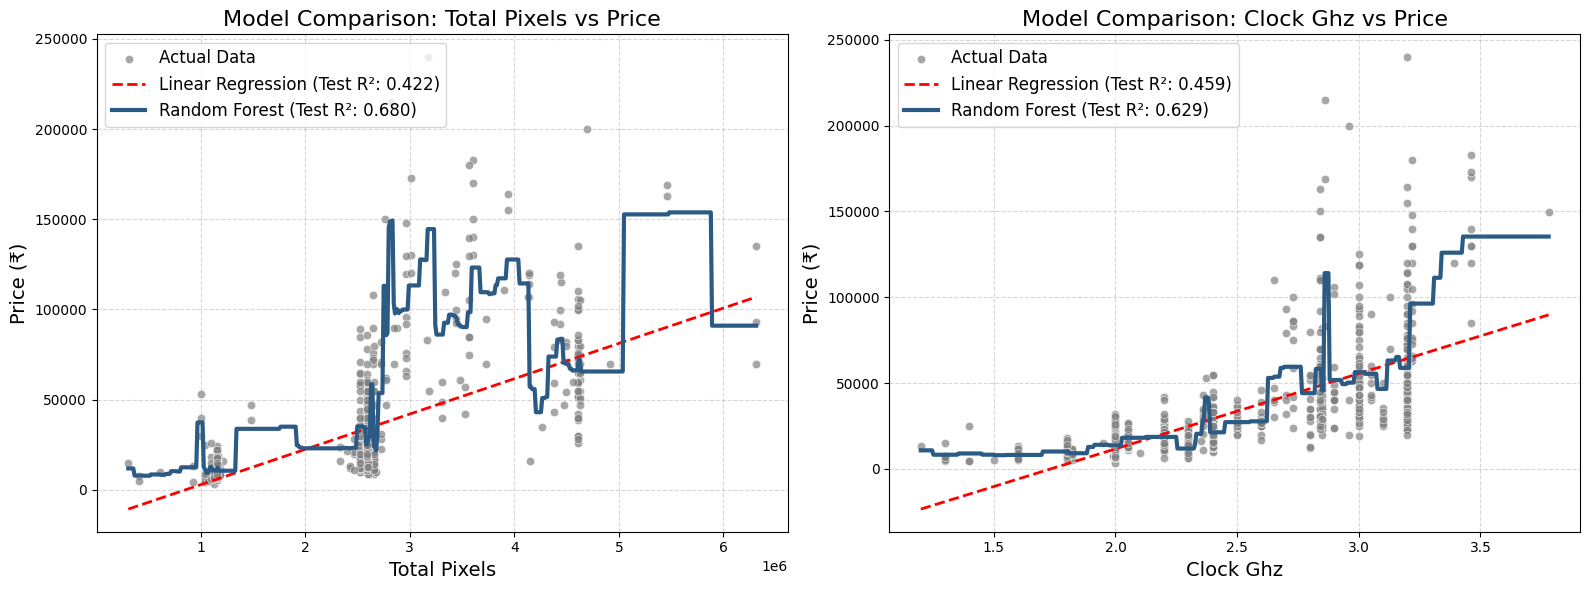

In [29]:
# 1. Define the features you want to compare
features_to_plot = ['total_pixels', 'clock_ghz']
target_col = 'price'

# Create the figure and the 1x2 grid OUTSIDE the loop
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Enumerate allows us to grab the index (i) to pick the correct subplot (left or right)
for i, feature in enumerate(features_to_plot):

    # Grab the specific axis for this loop (axes[0] for left, axes[1] for right)
    ax = axes[i]

    # 2. Isolate X and y
    X_single = df_cleaned[[feature]]
    y = df_cleaned[target_col]

    # Split into train/test so our R2 scores are mathematically valid (testing on unseen data)
    X_train, X_test, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=43)

    # 3. Train BOTH models
    # Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_r2 = r2_score(y_test, lr_model.predict(X_test))

    # Random Forest (max_depth=5 to keep the visualization clean)
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=43)
    rf_model.fit(X_train, y_train)
    rf_r2 = r2_score(y_test, rf_model.predict(X_test))

    # 4. Create the smooth X sequence for drawing the prediction lines
    x_range = np.linspace(X_single.min()[0], X_single.max()[0], 500).reshape(-1, 1)
    x_range_df = pd.DataFrame(x_range, columns=[feature])

    # Get predictions for the lines
    lr_line = lr_model.predict(x_range_df)
    rf_line = rf_model.predict(x_range_df)

    # 5. Generate the Plot directly on the specific 'ax'
    # Scatter the real data
    sns.scatterplot(data=df_cleaned, x=feature, y=target_col,
                    alpha=0.7, color='gray', label='Actual Data', ax=ax)

    # Plot the Linear Regression Line
    ax.plot(x_range_df, lr_line, color='red', linestyle='--', linewidth=2,
             label=f'Linear Regression (Test R²: {lr_r2:.3f})')

    # Plot the Random Forest Line
    ax.plot(x_range_df, rf_line, color='#2b5b84', linewidth=3,
             label=f'Random Forest (Test R²: {rf_r2:.3f})')

    # Formatting (Note: changed plt.title to ax.set_title, etc.)
    ax.set_title(f'Model Comparison: {feature.replace("_", " ").title()} vs Price', fontsize=16)
    ax.set_xlabel(feature.replace("_", " ").title(), fontsize=14)
    ax.set_ylabel('Price (₹)', fontsize=14)

    # Place legend in a clear spot
    ax.legend(fontsize=12, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)

# Save and Show OUTSIDE the loop once both subplots are built
plt.tight_layout()
plt.savefig('model_comparison_side_by_side.png', dpi=600)
plt.show()

# **Pricing Category Model Performance**

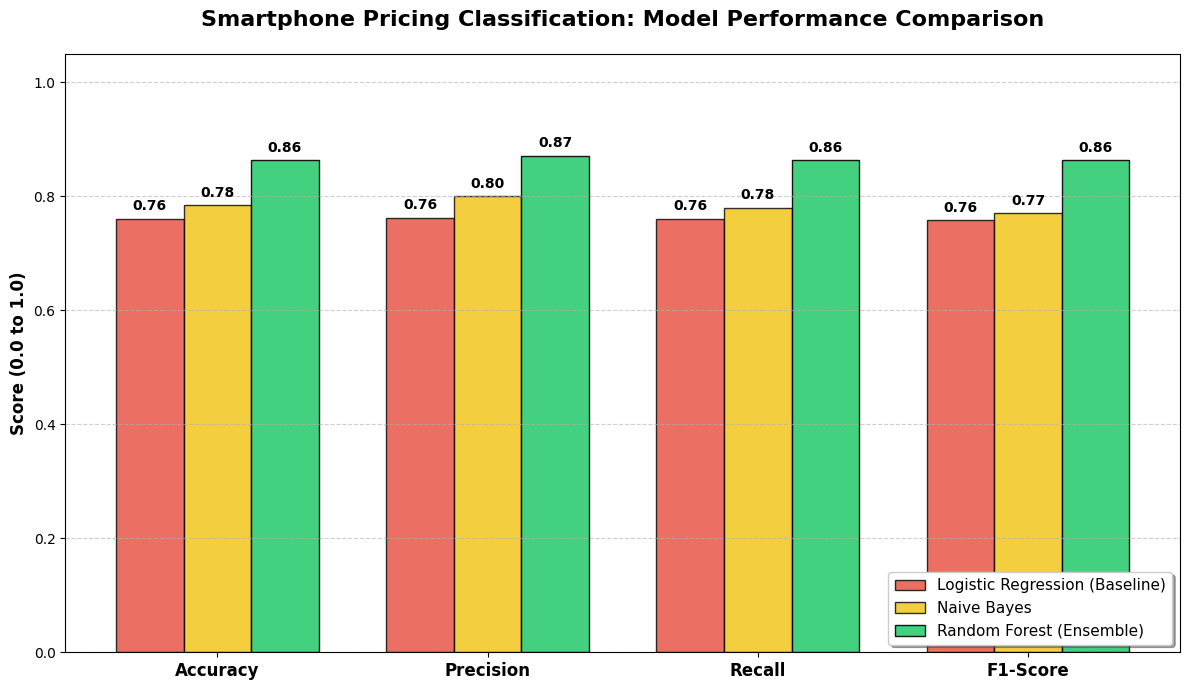

In [30]:
# 1. DATA COLLECTION: [Accuracy, Precision, Recall, F1-Score]
# Accuracy is the overall score; Precision/Recall/F1 are 'weighted averages' from reports.
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

lr_scores = [0.7605, 0.7620, 0.7605, 0.7580]
nb_scores = [0.7842, 0.8000, 0.7800, 0.7700]
rfc_scores = [0.8632, 0.8711, 0.8631, 0.8634]

# 2. PLOTTING SETUP
x = np.arange(len(metrics))
width = 0.25  # Width of the individual bars

plt.figure(figsize=(12, 7))

# 3. CREATE BARS
plt.bar(x - width, lr_scores, width, label='Logistic Regression (Baseline)', color='#e74c3c', edgecolor='black', alpha=0.8)
plt.bar(x, nb_scores, width, label='Naive Bayes', color='#f1c40f', edgecolor='black', alpha=0.8)
plt.bar(x + width, rfc_scores, width, label='Random Forest (Ensemble)', color='#2ecc71', edgecolor='black', alpha=0.9)

# 4. FORMATTING & LABELS
plt.title("Smartphone Pricing Classification: Model Performance Comparison", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Score (0.0 to 1.0)", fontsize=12, fontweight='bold')
plt.xticks(x, metrics, fontsize=12, fontweight='bold')
plt.ylim(0, 1.05) # Extra space for labels
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add numeric value labels on top of each bar
def add_value_labels(scores, x_pos):
    for i, v in enumerate(scores):
        plt.text(x_pos[i], v + 0.015, f"{v:.2f}", ha='center', fontsize=10, fontweight='bold')

add_value_labels(lr_scores, x - width)
add_value_labels(nb_scores, x)
add_value_labels(rfc_scores, x + width)

plt.tight_layout()
plt.show()

# **Rating Category Model Performance**

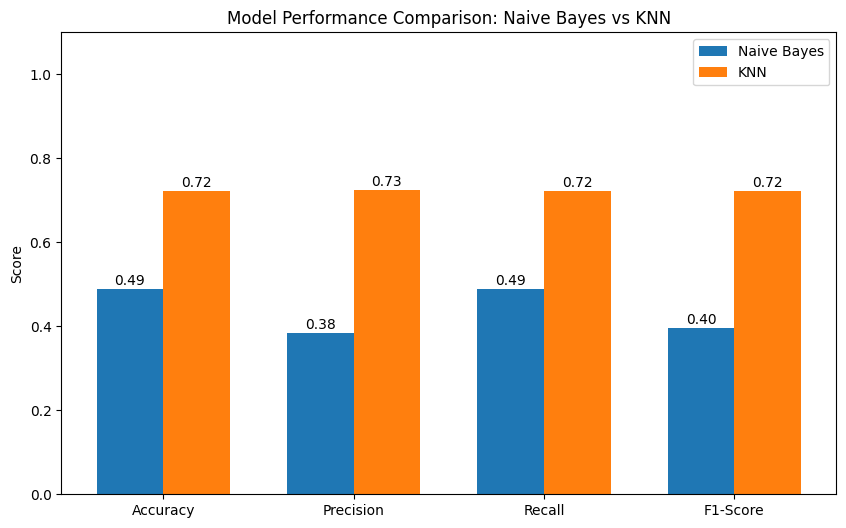

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =========================================================
# NAIVE BAYES METRICS
# =========================================================

nb_accuracy = accuracy_score(y_test_bayes2, y_pred_nb)
nb_precision = precision_score(y_test_bayes2, y_pred_nb, average='weighted', zero_division=0)
nb_recall = recall_score(y_test_bayes2, y_pred_nb, average='weighted', zero_division=0)
nb_f1 = f1_score(y_test_bayes2, y_pred_nb, average='weighted', zero_division=0)

# =========================================================
# KNN METRICS
# =========================================================

knn_accuracy = accuracy_score(y_test_model1, y_pred_model1)
knn_precision = precision_score(y_test_model1, y_pred_model1, average='weighted', zero_division=0)
knn_recall = recall_score(y_test_model1, y_pred_model1, average='weighted', zero_division=0)
knn_f1 = f1_score(y_test_model1, y_pred_model1, average='weighted', zero_division=0)

# =========================================================
# DATA FOR PLOTTING
# =========================================================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

naive_bayes_scores = [nb_accuracy, nb_precision, nb_recall, nb_f1]
knn_scores = [knn_accuracy, knn_precision, knn_recall, knn_f1]

x = np.arange(len(metrics))
width = 0.35

# =========================================================
# PLOT BAR CHART
# =========================================================

plt.figure(figsize=(10,6))

plt.bar(x - width/2, naive_bayes_scores, width, label='Naive Bayes')
plt.bar(x + width/2, knn_scores, width, label='KNN')

plt.xticks(x, metrics)

plt.ylabel("Score")
plt.title("Model Performance Comparison: Naive Bayes vs KNN")

plt.legend()

# Add values on top of bars
for i in range(len(metrics)):
    plt.text(i - width/2, naive_bayes_scores[i] + 0.01, f"{naive_bayes_scores[i]:.2f}", ha='center')
    plt.text(i + width/2, knn_scores[i] + 0.01, f"{knn_scores[i]:.2f}", ha='center')

plt.ylim(0, 1.1)

plt.show()